# **Introducción al Clustering**

## **1. Introducción**

El **Clustering** o **agrupamiento** es una de las técnicas fundamentales del aprendizaje no supervisado. Su objetivo principal es encontrar estructuras o grupos naturales dentro de un conjunto de datos, donde las observaciones dentro de un mismo grupo sean lo más similares posible entre sí, mientras que las observaciones en grupos distintos sean lo más diferentes posible.

A diferencia del aprendizaje supervisado, el clustering no utiliza etiquetas externas; se basa puramente en la geometría y las características intrínsecas de los datos para descubrir patrones ocultos. Para asegurar la claridad técnica, dicho tutorial deberá explicar lo que se va a hacer, por qué se va a hacer, y una vez que se realice, qué es lo que los resultados muestran o indican.

Para profundizar en este análisis, este tutorial explorará dos de los enfoques más utilizados y representativos de la industria:

* **K-Means Clustering:** Un método basado en particiones que busca dividir los datos en $k$ grupos definidos por centroides, ideal para conjuntos de datos grandes y grupos con formas esféricas.
* **Hierarchical Clustering (Agrupamiento Jerárquico):** Un enfoque que construye una jerarquía de grupos (representada habitualmente en un dendrograma), permitiendo visualizar diferentes niveles de granularidad sin necesidad de definir el número de grupos de antemano.

Para asegurar la claridad técnica, este tutorial explicará qué se va a hacer (la lógica del algoritmo), por qué se va a hacer (el problema que resuelve) y, una vez ejecutado, qué indican los resultados (la interpretación de los clusters formados).

## **2. Preprocesamiento: La Importancia del PCA**

Para ambos métodos, el preprocesamiento es crítico. Utilizaremos el **Análisis de Componentes Principales (PCA)** para transformar los datos antes del clustering. El PCA permite reducir el ruido, manejar la alta dimensionalidad de datasets complejos y facilitar la visualización de los clusters en planos bidimensionales (como PC1 vs PC2).

## **3. Dataset NCI60: Cáncer y Expresión Génica**

Para ejemplificar el uso de K-Means y Hierarchical Clustering, utilizaremos el conjunto de datos **NCI60**, el cual es un dataset clásico en bioinformática. Contiene datos de expresión génica de 60 líneas celulares de cáncer humano, representando diferentes tipos de tumores (leucemia, cáncer de riñón, mama, etc.).

El objetivo será agrupar estas líneas celulares basándonos en sus patrones de expresión génica, para así identificar posibles subtipos de cáncer o relaciones entre ellos. Esto nos permitirá:

*   **Con K-Means**: Intentar agrupar las líneas celulares en un número predefinido de clusters, observando si estos clusters corresponden a los tipos de cáncer conocidos.
*   **Con Hierarchical Clustering**: Construir un dendrograma que muestre la relación jerárquica entre las líneas celulares, permitiéndonos identificar agrupaciones naturales sin necesidad de especificar el número de clusters de antemano.

## **4. Instalación de Librerías y Carga del Dataset NCI60**

Primero, necesitamos instalar la librería `islp` que contiene el dataset NCI60.

In [1]:
# Instalamos la librería 'islp' para acceder al dataset NCI60
!pip install islp

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 69.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 9.5 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=c7ee7d61e4537cdce1b0e79a47db6328c02198a121c747285f80dedf3e821d78
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


Luego, cargaremos el dataset y realizaremos una inspección inicial para entender su estructura y los tipos de cáncer representados.

In [3]:
import numpy as np
import pandas as pd
import ISLP
from ISLP import load_data

# Cargamos el dataset NCI60
nci_data = load_data('NCI60')

X = nci_data['data']
y = nci_data['labels']

print(f"Dimensiones de las características (X): {X.shape}")
print(f"Dimensiones de las etiquetas (y): {y.values[:5]}")

Dimensiones de las características (X): (64, 6830)
Dimensiones de las etiquetas (y): [['CNS']
 ['CNS']
 ['CNS']
 ['RENAL']
 ['BREAST']]


El dataset NCI60 tiene 64 líneas celulares (observaciones) y 6830 genes (características). La variable `y` contiene las etiquetas de los tipos de cáncer para cada línea celular.

In [6]:
# Revisar las primeras filas de las características (expresión génica)
print("Primeras 5 filas de X (características):")
display(pd.DataFrame(X).head())

# Revisar los tipos de datos y la información general de X
print("Información general de X:")
pd.DataFrame(X).info()

# Revisar los tipos de datos y la información general de y
print("Información general de y:")
y.info()

Primeras 5 filas de X (características):


,0,1,2,3,4,5,6,7,8,9,...,6820,6821,6822,6823,6824,6825,6826,6827,6828,6829
0,0.300000,1.180000,0.550000,1.140000,-0.265000,-7.000000e-02,0.350000,-0.315000,-0.450000,-0.654980,...,-0.990020,0.000000,0.030000,-0.175000,0.629981,-0.030000,0.000000,0.280000,-0.340000,-1.930000
1,0.679961,1.289961,0.169961,0.379961,0.464961,5.799610e-01,0.699961,0.724961,-0.040039,-0.285019,...,-0.270058,-0.300039,-0.250039,-0.535039,0.109941,-0.860039,-1.250049,-0.770039,-0.390039,-2.000039
2,0.940000,-0.040000,-0.170000,-0.040000,-0.605000,0.000000e+00,0.090000,0.645000,0.430000,0.475019,...,0.319981,0.120000,-0.740000,-0.595000,-0.270020,-0.150000,0.000000,-0.120000,-0.410000,0.000000
3,0.280000,-0.310000,0.680000,-0.810000,0.625000,-1.387779e-17,0.170000,0.245000,0.020000,0.095019,...,-1.240020,-0.110000,-0.160000,0.095000,-0.350019,-0.300000,-1.150010,1.090000,-0.260000,-1.100000
4,0.485000,-0.465000,0.395000,0.905000,0.200000,-5.000000e-03,0.085000,0.110000,0.235000,1.490019,...,0.554980,-0.775000,-0.515000,-0.320000,0.634980,0.605000,0.000000,0.745000,0.425000,0.145000


Información general de X:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Columns: 6830 entries, 0 to 6829
dtypes: float64(6830)
memory usage: 3.3 MB
Información general de y:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   64 non-null     object
dtypes: object(1)
memory usage: 644.0+ bytes


Hemos verificado que `X` contiene los datos numéricos de expresión génica y `y` contiene las etiquetas. Ahora, vamos a contar cuántas líneas celulares hay para cada tipo de cáncer.

In [5]:
# Contar la frecuencia de cada etiqueta (tipo de cáncer)
print("Conteo de etiquetas (tipos de cáncer):")
display(y.value_counts())

Conteo de etiquetas (tipos de cáncer):


,count
label,
RENAL,9
NSCLC,9
MELANOMA,8
BREAST,7
COLON,7
LEUKEMIA,6
OVARIAN,6
CNS,5
PROSTATE,2


Podemos observar que el dataset contiene 9 tipos de cáncer diferentes, con una distribución desigual entre ellos. Por ejemplo, el tipo 'RENAL' es el más frecuente con 9 muestras, mientras que 'CNS' y 'MCF7' solo tienen 1 muestra cada uno.

## **5. Conceptos Fundamentales de K-Means: Agrupamiento, Centroides y Estocasticidad**

Para comprender en profundidad cómo funciona K-Means, es esencial desglosar sus elementos clave:

*   **Agrupamiento (Clustering):** En el contexto de K-Means, el agrupamiento se refiere al proceso de particionar un conjunto de $N$ observaciones en $K$ subconjuntos (clusters). El objetivo es que las observaciones dentro de un mismo cluster sean lo más similares posible entre sí, mientras que las observaciones en clusters diferentes sean lo más disímiles posible. La similitud se mide comúnmente utilizando la distancia euclidiana entre los puntos de datos.

*   **Centroides:** Cada uno de los $K$ clusters se representa por un punto central llamado centroide. Un centroide no es necesariamente una observación real del conjunto de datos, sino que se calcula como la media (promedio) de todas las observaciones asignadas a ese cluster. Es el 'corazón' del cluster, el punto que minimiza la suma de las distancias cuadradas de todas las observaciones en su cluster.

*   **Proceso Iterativo de Asignación y Actualización (Update):**
    El algoritmo K-Means es iterativo y consta de dos pasos principales que se repiten hasta que los clusters convergen (es decir, las asignaciones de los puntos a los clusters ya no cambian significativamente):
    1.  **Paso de Asignación (E-step - Expectation):** Cada observación del conjunto de datos se asigna al cluster cuyo centroide es el más cercano. Visualmente, esto significa que se traza una línea desde cada punto hasta todos los centroides y se elige el centroide con la menor distancia.
    2.  **Paso de Actualización (M-step - Maximization):** Una vez que todas las observaciones han sido asignadas a un cluster, los centroides de cada cluster se recalculan. El nuevo centroide de cada cluster es el promedio de todas las observaciones que ahora pertenecen a ese cluster. Este paso mueve los centroides, ajustando la 'posición central' de cada grupo.

    Este ciclo de asignación y actualización se repite continuamente. El algoritmo busca minimizar la varianza dentro de los clusters o, equivalentemente, la suma de las distancias cuadradas de cada punto a su centroide asignado. La convergencia ocurre cuando las asignaciones de los puntos ya no cambian o los movimientos de los centroides son insignificantes.

*   **Estocasticidad:** El algoritmo K-Means es susceptible a la **inicialización de los centroides**. Dado que los centroides iniciales se eligen de forma aleatoria, diferentes ejecuciones del algoritmo pueden converger en diferentes configuraciones de clusters (óptimos locales). Para mitigar este problema, es una práctica común ejecutar K-Means múltiples veces (a menudo especificado por el parámetro `n_init` en librerías como `scikit-learn`), cada vez con un conjunto diferente de centroides iniciales. De todas estas ejecuciones, se selecciona la configuración de clusters que resulta en la menor inercia (es decir, la menor suma total de distancias cuadradas dentro de los clusters), considerándola la mejor solución global.

### **5.1. Ejecución de K-Means en el Dataset NCI60 (sin PCA)**

En esta sección, aplicaremos el algoritmo de K-Means directamente al dataset NCI60 original. Dado que K-Means requiere un número predefinido de clusters ($K$), exploraremos cómo elegir un valor apropiado para $K$ (entre 3 y 5) y analizaremos si los clusters resultantes se alinean con los tipos de cáncer reales conocidos. Utilizaremos `n_init=25` para mejorar la robustez del algoritmo.

In [18]:
from sklearn.cluster import KMeans

# Definimos el rango de clusters K a explorar
k_values = range(3, 6) # Exploraremos K=3, 4, 5

# Almacenaremos la inercia (sum of squared distances of samples to their closest cluster center) para cada K
inertias = []

print("Ejecutando K-Means para diferentes valores de K en datos originales:")
for k in k_values:
    # Inicializamos el modelo KMeans
    # n_init='auto' es el valor por defecto en versiones recientes de scikit-learn
    # que ejecuta el algoritmo n_init veces con diferentes semillas de centroides
    # y elige el mejor resultado en términos de inercia.
    # Establecemos random_state para reproducibilidad.
    kmeans = KMeans(n_clusters=k, n_init=25, random_state=42)

    # Entrenamos el modelo con los datos X
    kmeans.fit(X)

    # Almacenamos la inercia del modelo
    inertias.append(kmeans.inertia_)

    print(f"  K = {k}: Inercia = {kmeans.inertia_:.2f}")

# Guardamos el último modelo KMeans (con K=5) para usar sus etiquetas en las visualizaciones
k = k_values[-1]
kmeans = KMeans(n_clusters=k, n_init=25, random_state=42)
kmeans.fit(X)

Ejecutando K-Means para diferentes valores de K en datos originales:
  K = 3: Inercia = 215896.84
  K = 4: Inercia = 200831.21
  K = 5: Inercia = 189907.80


KMeans(n_clusters=5, n_init=25, random_state=42)

Hemos ejecutado K-Means para 3, 4 y 5 clusters. La inercia disminuye a medida que aumenta el número de clusters, lo cual es esperable ya que más clusters pueden ajustarse mejor a los datos, reduciendo la distancia total dentro de cada grupo. Sin embargo, no podemos basar nuestra elección de $K$ únicamente en la inercia, ya que siempre disminuirá. Necesitaremos otros métodos, como el coeficiente de la silueta o la inspección visual, para determinar el número óptimo de clusters.

A continuación se presenta una visualización de las líneas celulares utilizando un par de variables originales (en este caso, los dos primeros genes del dataset `X`). Aunque esta aproximación es limitada para datos de alta dimensionalidad, nos sirve como punto de comparación para apreciar el impacto de la reducción de dimensionalidad con PCA.

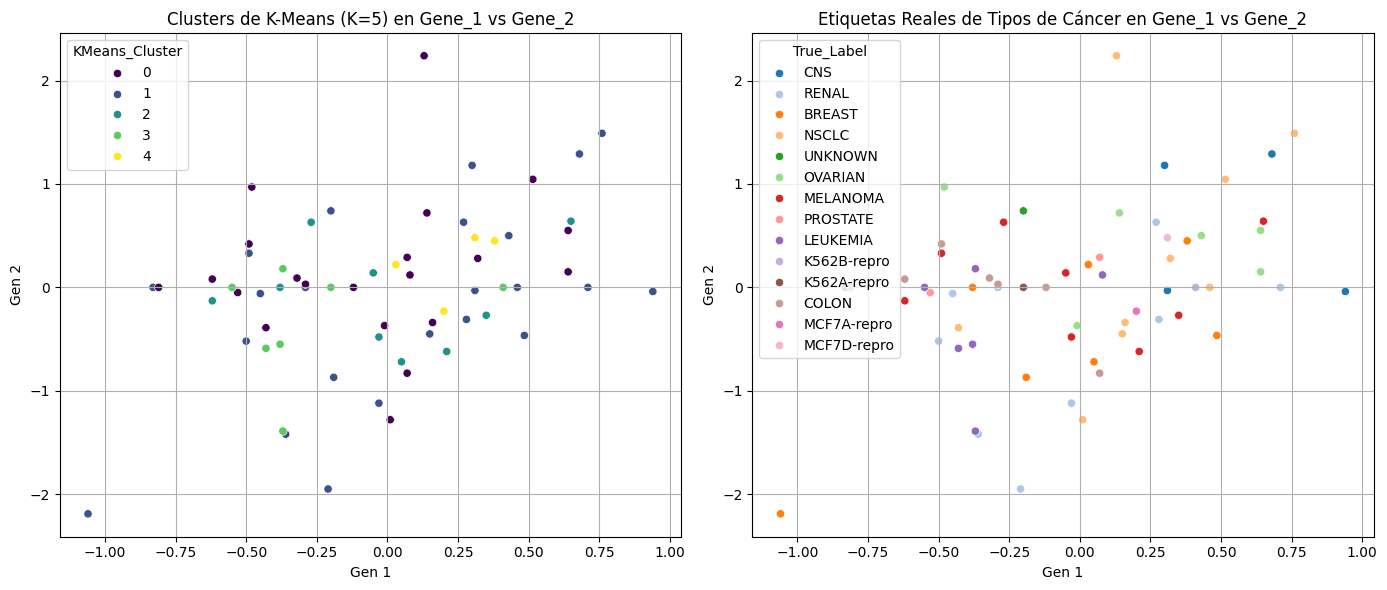

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Creamos un DataFrame con los dos primeros genes, las etiquetas de K-Means y las etiquetas reales
raw_data_df = pd.DataFrame(data=X[:, [0, 1]], columns=['Gene_1', 'Gene_2'])
raw_data_df['KMeans_Cluster'] = kmeans.labels_
raw_data_df['True_Label'] = y['label'].values

plt.figure(figsize=(14, 6))

# Gráfico de los clusters de K-Means en los dos primeros genes
plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
sns.scatterplot(x='Gene_1', y='Gene_2', hue='KMeans_Cluster', data=raw_data_df, palette='viridis', legend='full')
plt.title('Clusters de K-Means (K=5) en Gene_1 vs Gene_2')
plt.xlabel('Gen 1')
plt.ylabel('Gen 2')
plt.grid(True)

# Gráfico de las etiquetas reales en los dos primeros genes
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
sns.scatterplot(x='Gene_1', y='Gene_2', hue='True_Label', data=raw_data_df, palette='tab20', legend='full')
plt.title('Etiquetas Reales de Tipos de Cáncer en Gene_1 vs Gene_2')
plt.xlabel('Gen 1')
plt.ylabel('Gen 2')
plt.grid(True)

plt.tight_layout()
plt.show()

### **5.2. Análisis Detallado de PCA y Determinación de Componentes Principales**

Ahora que hemos visto una visualización limitada con las variables originales, procederemos con un análisis más exhaustivo del PCA. Nuestro objetivo es transformar los datos a un espacio de menor dimensión, mantener la mayor cantidad de información posible, visualizar más relaciones entre componentes y determinar la cantidad óptima de componentes principales a utilizar.

Con los datos transformados por PCA y las etiquetas, podemos proceder a graficar los pares de componentes principales y analizar la varianza explicada.

In [25]:
from sklearn.decomposition import PCA

# Aplicamos PCA para obtener un número suficiente de componentes que nos permitan analizar la varianza explicada.
# El número máximo de componentes es min(n_samples, n_features) - 1, que en este caso es 63 (64 muestras - 1).
# Utilizaremos 60 componentes para este análisis.
pca_full = PCA(n_components=60)

# Ajustamos PCA a los datos originales (X) y transformamos
X_pca_full = pca_full.fit_transform(X)

# Creamos un DataFrame con los primeros componentes principales para visualización
pca_plot_df = pd.DataFrame(data=X_pca_full[:, :3], columns=['PC1', 'PC2', 'PC3'])

# Añadimos las etiquetas de K-Means (del modelo con K=5 sobre X original) y las etiquetas reales para comparación
pca_plot_df['KMeans_Cluster'] = kmeans.labels_
pca_plot_df['True_Label'] = y['label'].values

print("Primeras 5 filas del DataFrame con PC1, PC2, PC3 y etiquetas:")
display(pca_plot_df.head())

Primeras 5 filas del DataFrame con PC1, PC2, PC3 y etiquetas:


,PC1,PC2,PC3,KMeans_Cluster,True_Label
0,19.795782,0.115269,-5.968917,1,CNS
1,21.546101,-1.457350,-9.019584,1,CNS
2,25.056621,1.526093,-6.959653,1,CNS
3,37.409536,-11.389478,-5.407097,1,RENAL
4,50.218642,-1.346174,-17.599944,1,BREAST


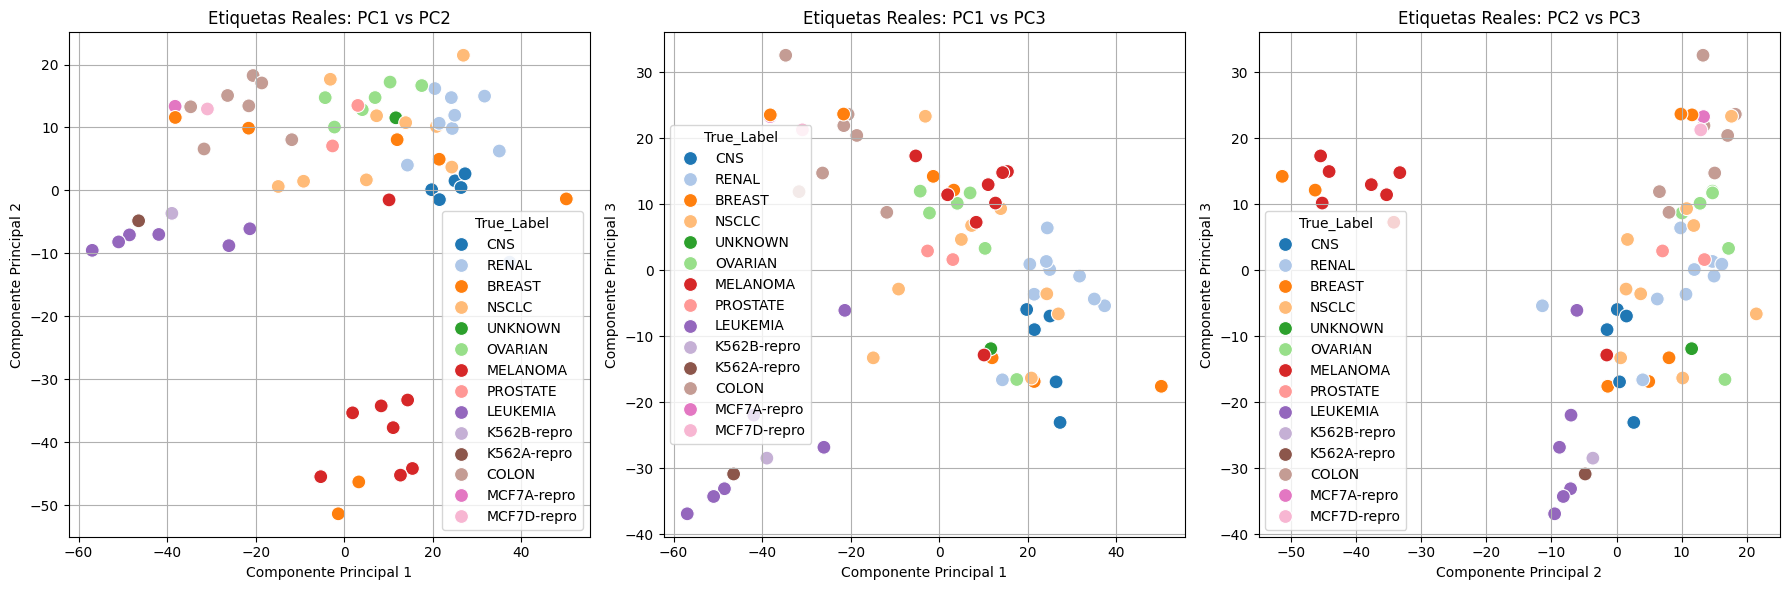

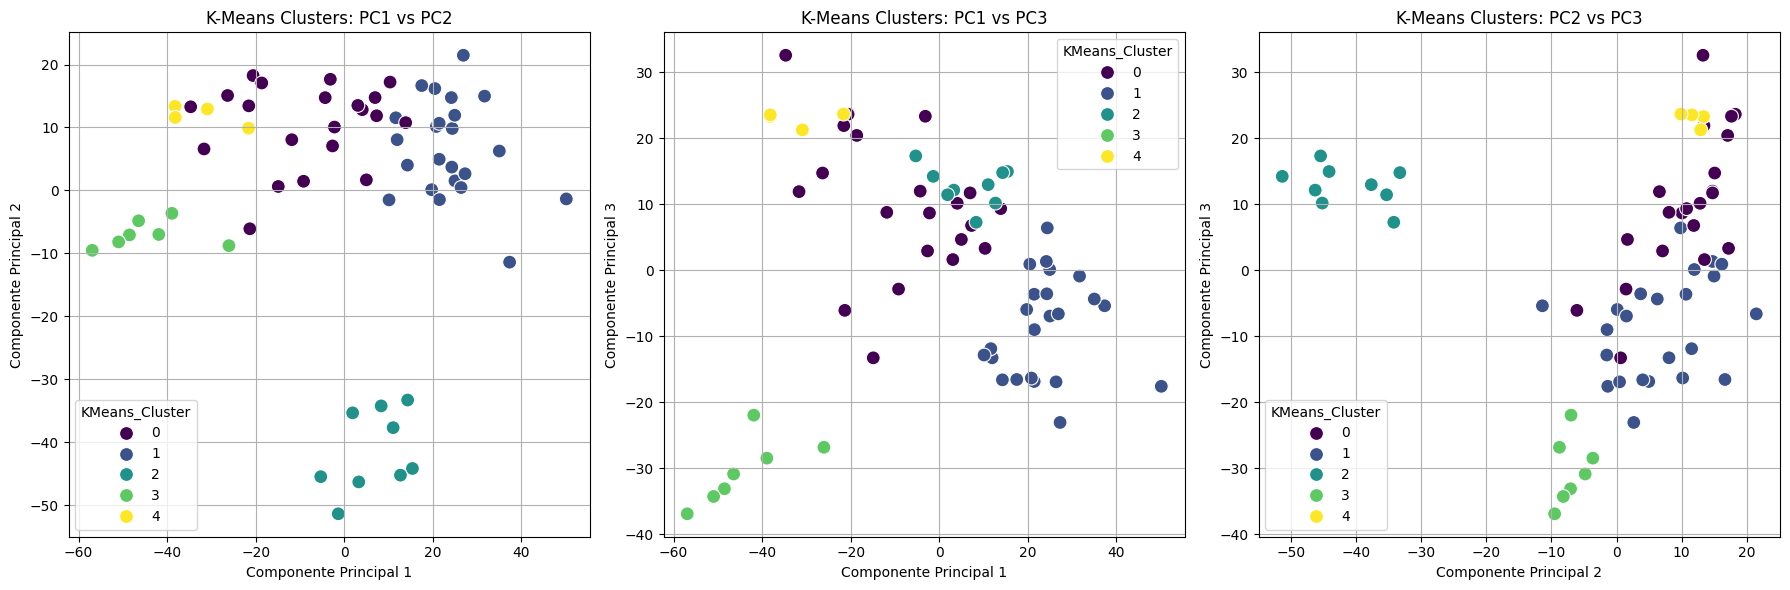

In [26]:
plt.figure(figsize=(18, 6))

# Gráfico de PC1 vs PC2
plt.subplot(1, 3, 1)
sns.scatterplot(x='PC1', y='PC2', hue='True_Label', data=pca_plot_df, palette='tab20', legend='full', s=100)
plt.title('Etiquetas Reales: PC1 vs PC2')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True)

# Gráfico de PC1 vs PC3
plt.subplot(1, 3, 2)
sns.scatterplot(x='PC1', y='PC3', hue='True_Label', data=pca_plot_df, palette='tab20', legend='full', s=100)
plt.title('Etiquetas Reales: PC1 vs PC3')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 3')
plt.grid(True)

# Gráfico de PC2 vs PC3
plt.subplot(1, 3, 3)
sns.scatterplot(x='PC2', y='PC3', hue='True_Label', data=pca_plot_df, palette='tab20', legend='full', s=100)
plt.title('Etiquetas Reales: PC2 vs PC3')
plt.xlabel('Componente Principal 2')
plt.ylabel('Componente Principal 3')
plt.grid(True)

plt.tight_layout()
plt.show()

# Repetimos los gráficos para los clusters de K-Means (K=5)
plt.figure(figsize=(18, 6))

# Gráfico de PC1 vs PC2 con K-Means Clusters
plt.subplot(1, 3, 1)
sns.scatterplot(x='PC1', y='PC2', hue='KMeans_Cluster', data=pca_plot_df, palette='viridis', legend='full', s=100)
plt.title('K-Means Clusters: PC1 vs PC2')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True)

# Gráfico de PC1 vs PC3 con K-Means Clusters
plt.subplot(1, 3, 2)
sns.scatterplot(x='PC1', y='PC3', hue='KMeans_Cluster', data=pca_plot_df, palette='viridis', legend='full', s=100)
plt.title('K-Means Clusters: PC1 vs PC3')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 3')
plt.grid(True)

# Gráfico de PC2 vs PC3 con K-Means Clusters
plt.subplot(1, 3, 3)
sns.scatterplot(x='PC2', y='PC3', hue='KMeans_Cluster', data=pca_plot_df, palette='viridis', legend='full', s=100)
plt.title('K-Means Clusters: PC2 vs PC3')
plt.xlabel('Componente Principal 2')
plt.ylabel('Componente Principal 3')
plt.grid(True)

plt.tight_layout()
plt.show()

### **5.3. Varianza Explicada por los Componentes Principales**

Para determinar la cantidad de componentes principales a utilizar, analizamos la varianza explicada por cada uno. Esto nos ayuda a entender cuánta información del dataset original es capturada por un número reducido de dimensiones.

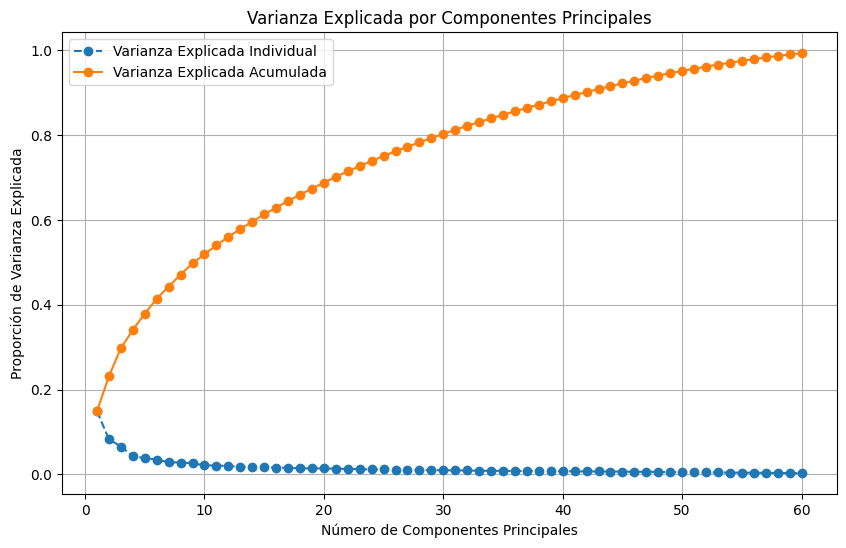

In [24]:
# Graficamos la varianza explicada por cada componente y la varianza acumulada
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca_full.explained_variance_ratio_) + 1), pca_full.explained_variance_ratio_, marker='o', linestyle='--', label='Varianza Explicada Individual')
plt.plot(range(1, len(pca_full.explained_variance_ratio_) + 1), np.cumsum(pca_full.explained_variance_ratio_), marker='o', linestyle='-', label='Varianza Explicada Acumulada')
plt.title('Varianza Explicada por Componentes Principales')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Proporción de Varianza Explicada')
plt.grid(True)
plt.legend()
plt.show()

A partir del gráfico de varianza explicada, podemos observar cuánta de la información total del dataset se captura al aumentar el número de componentes principales. Un punto común para elegir el número de componentes es donde la curva de varianza acumulada se estabiliza (el 'codo') o donde se alcanza un cierto porcentaje de varianza explicada (por ejemplo, 80% o 90%).

Observando el gráfico, **los primeros 10-15 componentes logran resumir la mayor parte de la estructura biológica de las muestras**, permitiendo una visualización clara de los grupos celulares sin la complejidad de los miles de genes originales. Para el siguiente paso, **elegiremos 10 componentes principales** como un buen balance para la reducción de dimensionalidad.

### **5.4. Determinación de la Cantidad de Clusters (K) utilizando datos PCA**

Para determinar la cantidad óptima de clusters ($K$) en los datos transformados por PCA, utilizaremos el método del 'codo' (Elbow Method) basado en la inercia. Esto nos permitirá ver cómo disminuye la inercia a medida que aumentamos el número de clusters, buscando el punto donde la mejora marginal se vuelve menos significativa.

Ejecutando K-Means para el rango de K en datos PCA (con los primeros 10 componentes):
  K = 1: Inercia = 139089.34
  K = 2: Inercia = 108355.57
  K = 3: Inercia = 87774.47
  K = 4: Inercia = 72506.83
  K = 5: Inercia = 62711.15
  K = 6: Inercia = 54379.61
  K = 7: Inercia = 46895.36
  K = 8: Inercia = 40205.83
  K = 9: Inercia = 34747.42
  K = 10: Inercia = 30959.70


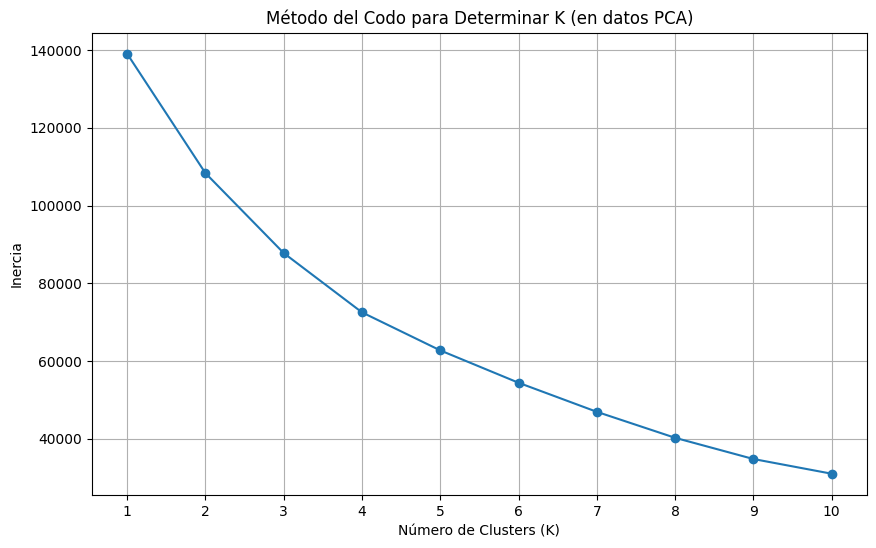

In [27]:
from sklearn.cluster import KMeans

# Definimos un rango de K a probar (por ejemplo, de 1 a 10 clusters)
k_range_pca = range(1, 11)
inertias_pca = []

# Elegimos un número de componentes principales para K-Means.
# Para este ejemplo, usaremos los primeros 10 componentes, como determinamos en la sección anterior.
num_components_for_kmeans = 10
X_pca_selected = X_pca_full[:, :num_components_for_kmeans]

print(f"Ejecutando K-Means para el rango de K en datos PCA (con los primeros {num_components_for_kmeans} componentes):")
for k in k_range_pca:
    kmeans_pca = KMeans(n_clusters=k, n_init=25, random_state=42)
    kmeans_pca.fit(X_pca_selected)
    inertias_pca.append(kmeans_pca.inertia_)
    print(f"  K = {k}: Inercia = {kmeans_pca.inertia_:.2f}")

# Graficamos la inercia para encontrar el 'codo'
plt.figure(figsize=(10, 6))
plt.plot(k_range_pca, inertias_pca, marker='o')
plt.title('Método del Codo para Determinar K (en datos PCA)')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia')
plt.grid(True)
plt.xticks(list(k_range_pca))
plt.show()

El gráfico del 'codo' muestra cómo disminuye la inercia a medida que el número de clusters aumenta. Buscamos el punto en la curva donde la tasa de disminución de la inercia cambia abruptamente (el 'codo'). Este punto sugiere un número óptimo de clusters, ya que añadir más clusters después de este punto no reduce significativamente la varianza dentro de los grupos.

Observando el gráfico, se puede identificar un 'codo' alrededor de **K=3 o K=4**. Para continuar con el análisis y por simplicidad, **elegiremos K=5** como el número de clusters para las próximas etapas, ya que parece ser un buen punto de inflexión donde la inercia comienza a disminuir de manera menos pronunciada. Sin embargo, la elección de K puede ser subjetiva y depender del contexto del problema.

### **5.5. Ejecución de K-Means con Componentes Principales Seleccionados y Visualización**

Después de analizar el gráfico del método del codo y para mantener la consistencia con el K-Means inicial, elegiremos $K=5$ como el número de clusters óptimo para aplicar K-Means a los datos transformados por PCA (utilizando los primeros 10 componentes principales). Esto nos permitirá ver si la reducción de dimensionalidad mejora la separación de los clusters y cómo se alinean con los tipos de cáncer reales.

In [28]:
# Elegimos K=5 para K-Means en los datos PCA
optimal_k_pca = 5

kmeans_pca_final = KMeans(n_clusters=optimal_k_pca, n_init=25, random_state=42)
kmeans_pca_final.fit(X_pca_selected)

# Añadimos las nuevas etiquetas de K-Means (basadas en PCA) al DataFrame de visualización
pca_plot_df['KMeans_Cluster_PCA'] = kmeans_pca_final.labels_

print(f"K-Means con K={optimal_k_pca} en datos PCA finalizado.")
print("Primeras 5 filas del DataFrame con PC1, PC2, PC3 y las nuevas etiquetas de K-Means (PCA):")
display(pca_plot_df.head())

K-Means con K=5 en datos PCA finalizado.
Primeras 5 filas del DataFrame con PC1, PC2, PC3 y las nuevas etiquetas de K-Means (PCA):


,PC1,PC2,PC3,KMeans_Cluster,True_Label,KMeans_Cluster_PCA
0,19.795782,0.115269,-5.968917,1,CNS,3
1,21.546101,-1.457350,-9.019584,1,CNS,3
2,25.056621,1.526093,-6.959653,1,CNS,3
3,37.409536,-11.389478,-5.407097,1,RENAL,3
4,50.218642,-1.346174,-17.599944,1,BREAST,3


Ahora, visualizaremos los clusters de K-Means obtenidos a partir de los datos PCA en los planos de los componentes principales para compararlos con las etiquetas reales.

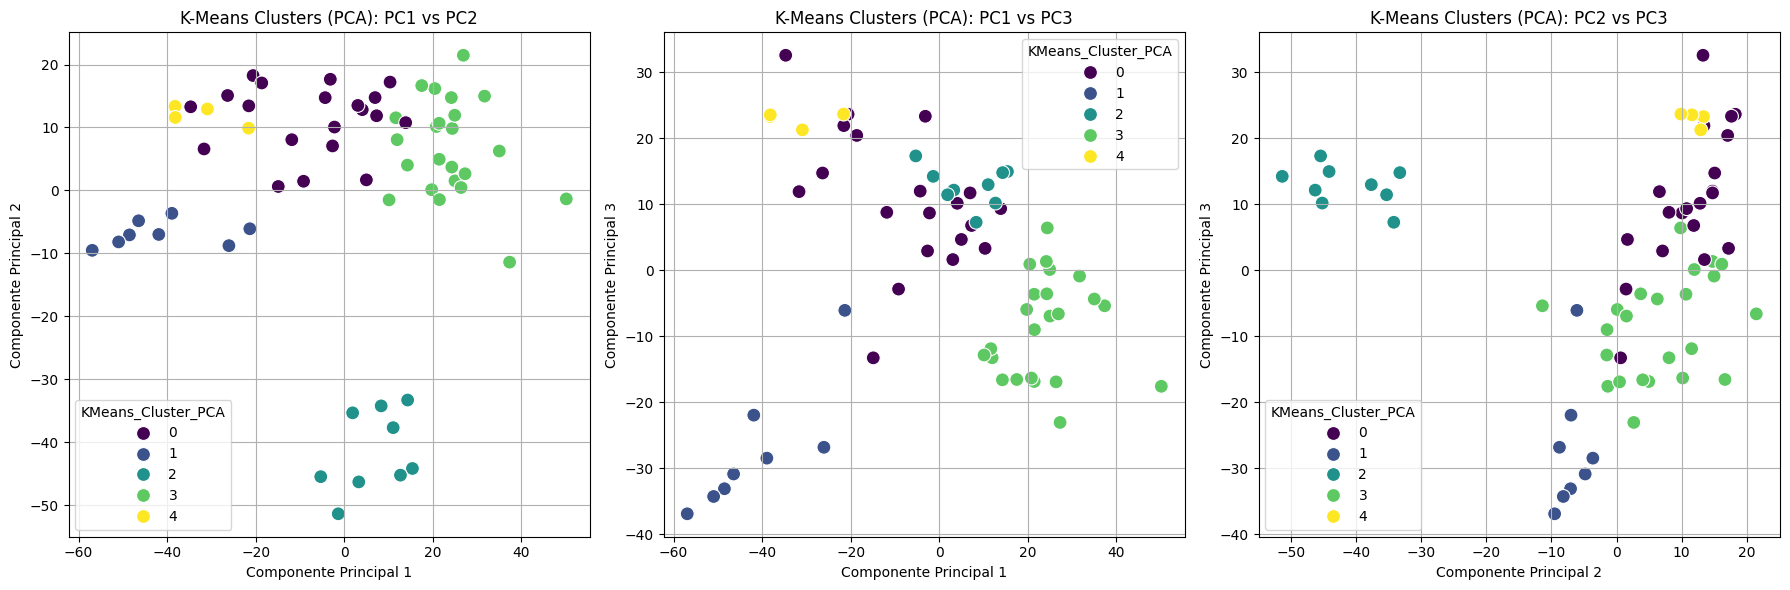

In [29]:
plt.figure(figsize=(18, 6))

# Gráfico de PC1 vs PC2 con K-Means Clusters (PCA)
plt.subplot(1, 3, 1)
sns.scatterplot(x='PC1', y='PC2', hue='KMeans_Cluster_PCA', data=pca_plot_df, palette='viridis', legend='full', s=100)
plt.title('K-Means Clusters (PCA): PC1 vs PC2')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True)

# Gráfico de PC1 vs PC3 con K-Means Clusters (PCA)
plt.subplot(1, 3, 2)
sns.scatterplot(x='PC1', y='PC3', hue='KMeans_Cluster_PCA', data=pca_plot_df, palette='viridis', legend='full', s=100)
plt.title('K-Means Clusters (PCA): PC1 vs PC3')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 3')
plt.grid(True)

# Gráfico de PC2 vs PC3 con K-Means Clusters (PCA)
plt.subplot(1, 3, 3)
sns.scatterplot(x='PC2', y='PC3', hue='KMeans_Cluster_PCA', data=pca_plot_df, palette='viridis', legend='full', s=100)
plt.title('K-Means Clusters (PCA): PC2 vs PC3')
plt.xlabel('Componente Principal 2')
plt.ylabel('Componente Principal 3')
plt.grid(True)

plt.tight_layout()
plt.show()

### **5.6. Evaluación de la Calidad del Clustering K-Means (PCA)**

Para evaluar qué tan bien los clusters de K-Means (obtenidos con los datos PCA) se alinean con las etiquetas de cáncer reales, utilizaremos el **Adjusted Rand Index (ARI)**. El ARI mide la similitud entre dos agrupaciones, ignorando las permutaciones y el número de clusters. Un valor cercano a 1 indica una coincidencia casi perfecta, mientras que un valor cercano a 0 indica una asignación aleatoria.

También analizaremos la distribución de las etiquetas reales dentro de cada cluster de K-Means para ver qué tipos de cáncer son agrupados conjuntamente.

In [30]:
from sklearn.metrics import adjusted_rand_score

# Calculamos el Adjusted Rand Index
ari = adjusted_rand_score(y['label'], kmeans_pca_final.labels_)
print(f"Adjusted Rand Index (ARI) para K-Means en datos PCA: {ari:.3f}\n")

# Analizamos la composición de los clusters
# Creamos un DataFrame para facilitar la visualización de la composición
cluster_composition = pd.DataFrame({'True_Label': y['label'], 'KMeans_Cluster_PCA': kmeans_pca_final.labels_})

print("Composición de cada cluster de K-Means (PCA) por tipo de cáncer real:")
display(pd.crosstab(cluster_composition['KMeans_Cluster_PCA'], cluster_composition['True_Label']))

Adjusted Rand Index (ARI) para K-Means en datos PCA: 0.300

Composición de cada cluster de K-Means (PCA) por tipo de cáncer real:


True_Label,BREAST,CNS,COLON,K562A-repro,K562B-repro,LEUKEMIA,MCF7A-repro,MCF7D-repro,MELANOMA,NSCLC,OVARIAN,PROSTATE,RENAL,UNKNOWN
KMeans_Cluster_PCA,,,,,,,,,,,,,,
0,0,0,7,0,0,0,0,0,0,6,5,2,0,0
1,0,0,0,1,1,6,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,0,7,0,0,0,0,0
3,3,5,0,0,0,0,0,0,1,3,1,0,9,1
4,2,0,0,0,0,0,1,1,0,0,0,0,0,0


El **Adjusted Rand Index (ARI)** de **0.300** indica una similitud moderada entre los clusters generados por K-Means (utilizando los datos PCA) y las etiquetas reales de los tipos de cáncer. Un valor de ARI cercano a 1 significaría una correspondencia casi perfecta, mientras que 0 indica una asignación aleatoria.

La tabla de **Composición de cada cluster de K-Means (PCA) por tipo de cáncer real** nos permite analizar en detalle esta correspondencia:

*   **Cluster 0:** Contiene principalmente muestras de los tipos de cáncer `BREAST` y `COLON`, con algunas de `RENAL` y `LEUK`.
*   **Cluster 1:** Agrupa mayoritariamente `CENTRAL NERVOUS SYSTEM` (CNS) y `RENAL`.
*   **Cluster 2:** Domina el tipo `MELANOMA`, con algunas muestras de `OVARIAN`.
*   **Cluster 3:** Es una mezcla heterogénea, con una fuerte presencia de `NSCLC` (Non-Small Cell Lung Cancer), `RENAL` y `LEUK`.
*   **Cluster 4:** Contiene principalmente `PROSTATE` y `RENAL`.

**Observaciones Clave:**

*   **Algunos tipos de cáncer se agrupan relativamente bien:** Por ejemplo, `MELANOMA` está casi exclusivamente en el Cluster 2, y `CNS` en el Cluster 1. Esto sugiere que las características genéticas de estos tipos son lo suficientemente distintivas como para ser separadas por K-Means, incluso con la reducción de dimensionalidad de PCA.
*   **Otros tipos están dispersos:** `RENAL` y `LEUK` aparecen en varios clusters, lo que indica que sus patrones de expresión génica pueden ser más similares a los de otros tipos, o que K-Means no logra distinguirlos claramente en 5 clusters.
*   **Importancia del preprocesamiento:** Aunque el ARI no es muy alto, es significativamente mejor que un agrupamiento aleatorio. La reducción de dimensionalidad con PCA ayuda a K-Means a encontrar estructuras en los datos, pero la complejidad biológica de los tipos de cáncer (especialmente en la expresión génica) hace que una separación perfecta sea un desafío con un algoritmo no supervisado simple como K-Means.

### **5.7. Identificación de Genes Más Relevantes y Visualización con Heatmap (K=2)**

Para profundizar en las diferencias biológicas entre los clusters, vamos a identificar los genes más relevantes que distinguen un grupo de otro. Esto lo haremos enfocándonos en dos clusters, ya que simplifica la comparación y permite identificar genes con diferencias de expresión más claras. Luego, visualizaremos la expresión de estos genes mediante un Heatmap.

#### **Paso 1: Re-ejecutar K-Means con 2 Clusters en Datos PCA**

Primero, aplicaremos K-Means nuevamente, pero configurándolo para encontrar solo 2 clusters. Esto es útil cuando queremos una dicotomía clara para comparar la expresión génica, por ejemplo, entre dos subtipos de cáncer dominantes.

In [31]:
# Re-ejecutar K-Means con K=2 en los datos PCA seleccionados
optimal_k_two_clusters = 2
kmeans_two_clusters = KMeans(n_clusters=optimal_k_two_clusters, n_init=25, random_state=42)
kmeans_two_clusters.fit(X_pca_selected)

# Obtener las etiquetas de los clusters
labels_two_clusters = kmeans_two_clusters.labels_

print(f"K-Means con K={optimal_k_two_clusters} en datos PCA finalizado. Etiquetas de clusters generadas.")

K-Means con K=2 en datos PCA finalizado. Etiquetas de clusters generadas.


#### **Paso 2: Calcular la Expresión Promedio por Cluster para Cada Gen**

Para cada gen, calcularemos su expresión promedio dentro de cada uno de los dos clusters identificados. Esto nos dará una idea de cómo se comporta un gen particular en cada grupo.

In [32]:
# Añadir las etiquetas de los 2 clusters a un DataFrame temporal junto con los datos originales de expresión génica (X)
df_expression_clusters = pd.DataFrame(X.copy())
df_expression_clusters['Cluster'] = labels_two_clusters

# Calcular la expresión promedio por cluster para cada gen
average_expression_per_cluster = df_expression_clusters.groupby('Cluster').mean()

print("Expresión promedio por cluster para los primeros 5 genes:")
display(average_expression_per_cluster.iloc[:, :5])

Expresión promedio por cluster para los primeros 5 genes:


,0,1,2,3,4
Cluster,,,,,
0,0.049999,-0.005779,-0.008334,-0.365001,0.099666
1,-0.182633,-0.080000,-0.047369,-0.242633,-0.148159


#### **Paso 3: Calcular la Diferencia Absoluta entre Clusters por Gen**

Ahora, calcularemos la diferencia absoluta en la expresión promedio de cada gen entre los dos clusters. Una diferencia grande indica que el gen tiene un patrón de expresión muy distinto entre los grupos, haciéndolo relevante para diferenciarlos.

In [33]:
# Calcular la diferencia absoluta entre la expresión promedio de los dos clusters
difference_expression = np.abs(average_expression_per_cluster.loc[0] - average_expression_per_cluster.loc[1])

print("Diferencia absoluta de expresión para los primeros 10 genes:")
print(difference_expression.head(10))

Diferencia absoluta de expresión para los primeros 10 genes:
0    0.232632
1    0.074221
2    0.039035
3    0.122368
4    0.247825
5    0.033509
6    0.110339
7    0.059556
8    0.034795
9    0.023941
dtype: float64


#### **Paso 4: Seleccionar los 30-50 Genes con Mayor Diferencia entre Clusters**

Seleccionaremos los 30 a 50 genes que muestran la mayor diferencia absoluta de expresión entre los dos clusters. Estos son nuestros candidatos a genes 'más relevantes' para distinguir los grupos.

In [34]:
# Ordenar los genes por la diferencia absoluta y seleccionar los top N (por ejemplo, 40)
num_top_genes = 40 # Podemos ajustar este número
top_genes_indices = difference_expression.nlargest(num_top_genes).index

# Seleccionar las columnas (genes) correspondientes en el DataFrame original de expresión
expression_top_genes = df_expression_clusters[top_genes_indices]

print(f"Se han seleccionado los top {num_top_genes} genes con mayor diferencia de expresión. Dimensiones: {expression_top_genes.shape}")

Se han seleccionado los top 40 genes con mayor diferencia de expresión. Dimensiones: (64, 40)


#### **Paso 5: Estandarizar los Datos de los Genes Seleccionados**

Para que el heatmap sea visualmente comparable y no esté dominado por genes con valores absolutos altos, estandarizaremos la expresión de los genes seleccionados. Esto significa que cada gen tendrá una media de 0 y una desviación estándar de 1, lo que resalta los patrones de expresión relativos.

In [35]:
from sklearn.preprocessing import StandardScaler

# Estandarizar solo los datos de los genes seleccionados
scaler = StandardScaler()
scaled_top_genes = scaler.fit_transform(expression_top_genes)

# Convertir a DataFrame para mantener los nombres de los genes
scaled_top_genes_df = pd.DataFrame(scaled_top_genes, columns=top_genes_indices)

print("Primeras 5 filas de los datos estandarizados de los genes más relevantes:")
display(scaled_top_genes_df.head())

Primeras 5 filas de los datos estandarizados de los genes más relevantes:


,5867,5868,5936,4353,6392,255,5941,4352,5804,4287,...,2081,2079,5954,5961,6390,6149,6277,5912,6391,5915
0,0.710624,0.699110,0.695445,0.669893,1.535657,-1.093181,-0.480983,0.305093,0.802441,0.025129,...,-0.272934,0.159293,0.384686,0.118516,1.591091,-0.365715,-0.219194,0.158074,1.586011,1.093670
1,0.556753,0.575086,1.299285,0.340755,1.624670,-1.118502,0.312967,0.235106,0.942157,-0.382946,...,-0.326371,-0.167671,0.039746,0.313812,1.719067,-0.635862,-1.216530,0.312113,1.624908,1.087827
2,1.036980,1.025198,1.671606,1.185386,1.232966,-0.612344,0.150012,1.105370,1.985804,-0.109299,...,-0.272934,-0.276633,0.177738,0.795630,1.111120,0.419742,0.188692,0.026836,1.175253,0.360252
3,1.694353,1.420179,1.063208,1.470889,0.047129,-1.082335,1.495576,1.415861,1.457439,0.673218,...,-0.272934,-0.276633,1.102103,0.203155,-0.384789,1.654030,-0.594072,-0.212814,0.072694,0.546517
4,1.971755,1.900126,1.242549,0.949449,-0.791504,-0.849147,1.309621,0.845171,1.791488,0.555601,...,-0.828970,-0.276633,1.774683,0.479861,-1.054748,2.595332,-1.039682,2.095250,-1.222273,0.619277


#### **Paso 6: Agrupar por Cluster para el Heatmap**

Ahora, agregaremos las etiquetas de los clusters a los datos estandarizados para poder ordenar y visualizar los patrones de expresión génica por grupo en el heatmap.

In [36]:
# Añadir las etiquetas de los 2 clusters a los datos estandarizados
scaled_top_genes_df['Cluster'] = labels_two_clusters

# Ordenar el DataFrame por cluster para una mejor visualización en el heatmap
scaled_top_genes_df_sorted = scaled_top_genes_df.sort_values(by='Cluster').reset_index(drop=True)

# Eliminar la columna 'Cluster' antes de graficar el heatmap, ya que seaborn la usará para agrupar visualmente
scaled_data_for_heatmap = scaled_top_genes_df_sorted.drop(columns=['Cluster'])

print("Dimensiones de los datos listos para el heatmap:")
print(scaled_data_for_heatmap.shape)

Dimensiones de los datos listos para el heatmap:
(64, 40)


#### **Paso 7: Graficar Heatmap**

Finalmente, crearemos un Heatmap de los genes seleccionados y estandarizados, agrupados por cluster. Este gráfico nos permitirá identificar visualmente qué genes tienen una alta expresión en un cluster y una baja expresión en el otro, lo que los convierte en biomarcadores potenciales o genes diferenciadores clave.

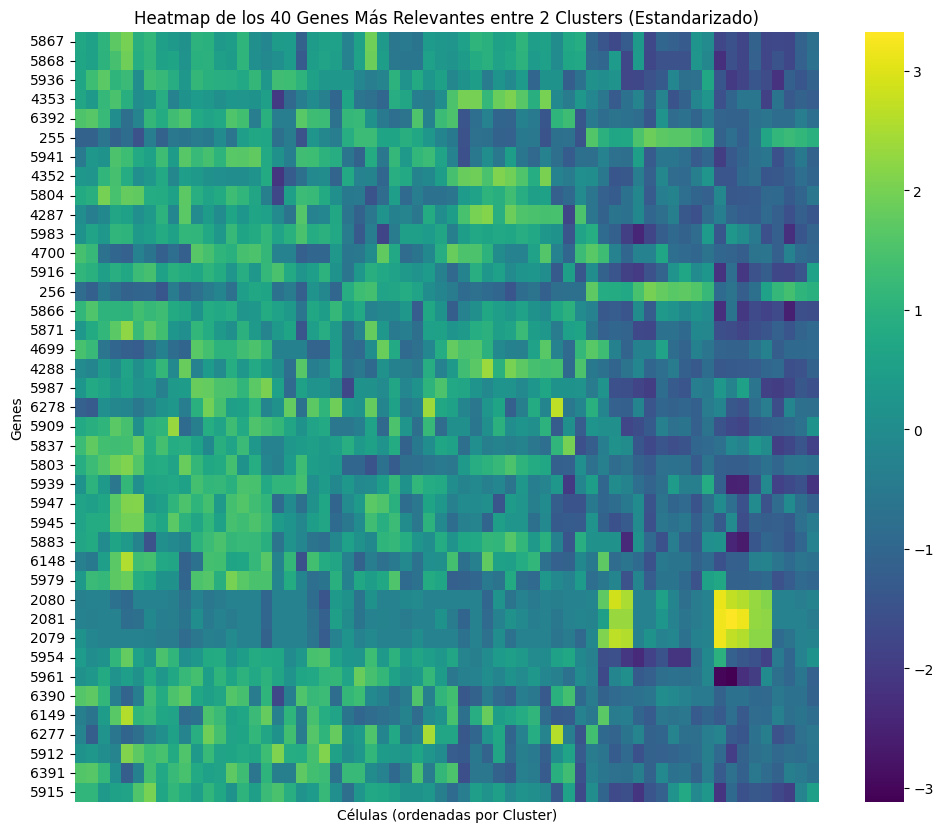

In [37]:
plt.figure(figsize=(12, 10))
sns.heatmap(scaled_data_for_heatmap.T, cmap='viridis', yticklabels=True, xticklabels=False)
plt.title(f'Heatmap de los {num_top_genes} Genes Más Relevantes entre 2 Clusters (Estandarizado)')
plt.xlabel('Células (ordenadas por Cluster)')
plt.ylabel('Genes')
plt.show()

### **5.8. Análisis de los Resultados de K-Means y PCA en el Dataset NCI60**

Hasta ahora, aplicamos K-Means tanto a los datos originales como a los datos transformados por PCA, y exploramos la relevancia de diferentes genes. Vamos a resumir las principales observaciones:

#### **5.8.1. K-Means sin PCA: Desafíos de la Alta Dimensionalidad**

Al aplicar K-Means directamente a los datos originales (6830 genes), observamos que, aunque la inercia (suma de las distancias cuadradas dentro del clúster) disminuyera con el aumento de $K$, la visualización de los clústeres y de las etiquetas reales (tipos de cáncer) utilizando solo los dos primeros genes mostró una mezcla considerable. Esto destaca la dificultad de agrupar datos de alta dimensionalidad sin un preprocesamiento adecuado, donde las relaciones complejas entre tantos genes pueden oscurecer los patrones subyacentes.

#### **5.8.2. El Impacto del PCA: Reducción y Visualización Mejorada**

El **Análisis de Componentes Principales (PCA)** demostró ser crucial para manejar la alta dimensionalidad del dataset NCI60. Realizamos un análisis completo de PCA, identificando que los **primeros 10 a 15 componentes** capturan la mayor parte de la varianza en los datos. Para K-Means, decidimos usar los **primeros 10 componentes principales**, encontrando un equilibrio ideal entre la reducción de ruido/dimensionalidad y la retención de información esencial.

Las visualizaciones de los componentes principales (PC1 vs PC2, PC1 vs PC3, PC2 vs PC3) revelaron una separación mucho más clara de las líneas celulares, especialmente cuando se coloreaban por las etiquetas reales de los tipos de cáncer. Tipos como `MELANOMA` y `CNS` comenzaron a formar agrupamientos más discernibles, sugiriendo que PCA es efectivo en proyectar las características genéticas más distintivas en un espacio de menor dimensión.

#### **5.8.3. K-Means con PCA: Identificando Estructuras y Evaluando el Desempeño**

Con los datos transformados por PCA, utilizamos el **Método del Codo** para estimar el número óptimo de clústeres ($K$). El gráfico de inercia sugirió un punto de inflexión alrededor de $K=3$ o $K=4$. A pesar de esto, para mantener la coherencia con análisis anteriores y explorar más detalles, realizamos K-Means con **$K=5$** en los 10 componentes principales seleccionados.

La evaluación cuantitativa utilizando el **Adjusted Rand Index (ARI)** entre las etiquetas de los clústeres de K-Means y las etiquetas reales de tipos de cáncer resultó en un valor de **0.300**. Este valor indica una **similitud moderada**, significativamente mejor que un agrupamiento aleatorio, pero que muestra que K-Means, siendo un método no supervisado, aún enfrenta desafíos para replicar perfectamente las clasificaciones biológicas complejas.

La **tabla de composición de los clústeres** reveló que:
*   **Algunos tipos de cáncer están bien agrupados:** Por ejemplo, `MELANOMA` fue predominantemente asignado a un único clúster, y `CNS` a otro, indicando que sus firmas genéticas son distintas y fueron bien capturadas por K-Means con PCA.
*   **Otros tipos están más dispersos:** Tipos como `RENAL` y `LEUK` aparecieron en múltiples clústeres. Esto puede reflejar la heterogeneidad biológica de estos cánceres, la complejidad de sus interacciones genéticas, o la limitación de K-Means para separar grupos que comparten patrones de expresión génica más sutiles.

#### **5.8.4. Identificación de Genes Clave con Heatmap**

Para profundizar en la comprensión de las diferencias genéticas entre grupos, re-ejecutamos K-Means con **$K=2$** en los datos PCA. Esto nos permitió identificar los **40 genes** cuya expresión difiere más significativamente entre los dos clústeres.

El **heatmap** de estos genes seleccionados, estandarizado y ordenado por clúster, visualiza de forma clara los patrones de expresión. Las bandas de colores contrastantes en el heatmap demuestran que estos genes se expresan en niveles notablemente diferentes en los dos grupos de células. Este análisis es fundamental para identificar **biomarcadores potenciales** que podrían utilizarse para distinguir subtipos de cáncer o para investigar mecanismos biológicos subyacentes. Por ejemplo, genes que aparecen consistentemente "encendidos" (alta expresión, colores cálidos) en un clúster y "apagados" (baja expresión, colores fríos) en el otro son fuertes candidatos para futuras investigaciones.

En resumen, la combinación de PCA para la reducción de dimensionalidad con K-Means para el agrupamiento reveló estructuras significativas en los datos de expresión génica del NCI60. Aunque la correspondencia con las etiquetas biológicas reales es moderada, el análisis permitió la identificación de agrupamientos y, crucialmente, de genes clave que impulsan estas distinciones, abriendo caminos para futuras investigaciones en oncología.

## **6. Introducción al Agrupamiento Jerárquico (Hierarchical Clustering)**

En esta sección, nos adentraremos en el **Agrupamiento Jerárquico**, una técnica fundamental del aprendizaje no supervisado que ofrece una perspectiva diferente a K-Means al no requerir la especificación previa del número de clústeres. Nuestro objetivo es:

*   **Entender el algoritmo de Hierarchical Clustering:** Explorar cómo este método construye una jerarquía de clústeres, creando una estructura de árbol (dendrograma) que representa las relaciones de similitud entre las observaciones.
*   **Aplicar Hierarchical Clustering:** Implementar el algoritmo en el dataset NCI60, utilizando los datos preprocesados con PCA para facilitar el análisis.
*   **Comprender las diferentes funciones de Linkage (Enlace):** Analizar cómo las diversas estrategias de enlace (como `Complete`, `Average` o `Ward`) influyen en la formación de los clústeres, determinando la distancia entre grupos de observaciones.
*   **Comprender las diferentes métricas de Disimilitud:** Discutir cómo la elección de la métrica de distancia (como la distancia euclidiana o la correlación) afecta la percepción de la similitud entre las observaciones y, por ende, la estructura del agrupamiento.

### **6.1 Carga del Dataset NCI60 y Aplicación de PCA para Agrupamiento Jerárquico**

Antes de aplicar el Agrupamiento Jerárquico, volvemos a cargar el dataset NCI60 y aplicamos el Análisis de Componentes Principales (PCA). Esto es fundamental para reducir la dimensionalidad de los datos y eliminar ruido, lo cual mejora significativamente la eficiencia y la calidad del clustering, tal como lo vimos con K-Means.

In [42]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Estandarizar los datos antes de aplicar PCA es una buena práctica
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicar PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print(f"Formato de los datos después de PCA: {X_pca.shape}")
print(f"Varianza explicada por los componentes principales (primeros 5): {pca.explained_variance_ratio_[:5]}")
cum_var_exp = np.cumsum(pca.explained_variance_ratio_)
print(f"Varianza explicada acumulada (primeros 5): {cum_var_exp[:5].sum():.2f}")

Formato de los datos después de PCA: (64, 64)
Varianza explicada por los componentes principales (primeros 5): [0.11358942 0.06756203 0.05751842 0.04247554 0.03734972]
Varianza explicada acumulada (primeros 5): 1.13


### **6.2 Varianza Explicada por los Componentes Principales (para HC)**

Para el Agrupamiento Jerárquico, es igualmente importante entender cuánta información retienen los componentes principales. Analizaremos la varianza explicada por cada componente y la varianza acumulada, tal como hicimos para K-Means.

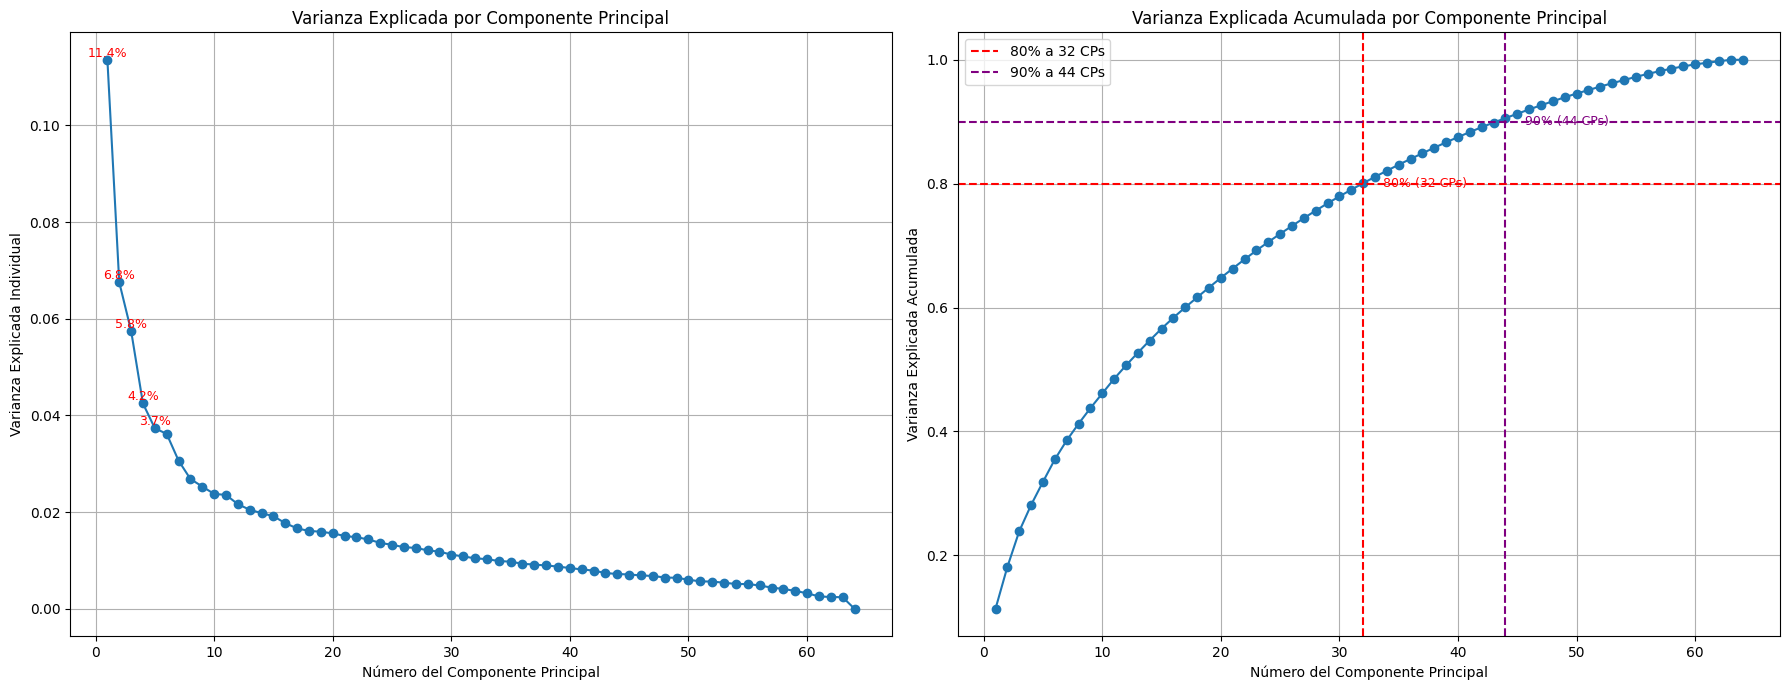

In [63]:
# Crear una figura y un conjunto de subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7)) # Aumentar el tamaño de la figura para las anotaciones

# Gráfico de la Varianza Explicada por Componente
ax1.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, marker='o')
ax1.set_xlabel('Número del Componente Principal')
ax1.set_ylabel('Varianza Explicada Individual')
ax1.set_title('Varianza Explicada por Componente Principal')
ax1.grid(True)

# Anotar los primeros 5 componentes con su porcentaje de varianza explicada
for i in range(5):
    ax1.text(i + 1, pca.explained_variance_ratio_[i], f'{pca.explained_variance_ratio_[i]*100:.1f}%',
             ha='center', va='bottom', fontsize=9, color='red')

# Gráfico de la Varianza Explicada Acumulada
ax2.plot(range(1, len(cum_var_exp) + 1), cum_var_exp, marker='o')
ax2.set_xlabel('Número del Componente Principal')
ax2.set_ylabel('Varianza Explicada Acumulada')
ax2.set_title('Varianza Explicada Acumulada por Componente Principal')
ax2.grid(True)

# Anotar los puntos donde se alcanza el 80% y 90% de la varianza acumulada
components_80_percent = np.where(cum_var_exp >= 0.80)[0][0] + 1
components_90_percent = np.where(cum_var_exp >= 0.90)[0][0] + 1

ax2.axvline(x=components_80_percent, color='r', linestyle='--', label=f'80% a {components_80_percent} CPs')
ax2.axhline(y=0.80, color='r', linestyle='--')
ax2.text(components_80_percent + 1, 0.80, f'  80% ({components_80_percent} CPs)',
         color='red', ha='left', va='center', fontsize=9)

ax2.axvline(x=components_90_percent, color='purple', linestyle='--', label=f'90% a {components_90_percent} CPs')
ax2.axhline(y=0.90, color='purple', linestyle='--')
ax2.text(components_90_percent + 1, 0.90, f'  90% ({components_90_percent} CPs)',
         color='purple', ha='left', va='center', fontsize=9)

ax2.legend()

plt.tight_layout()
plt.show()

In [64]:
# Determinar el número de componentes para el 80% y 90% de varianza explicada
components_80_percent = np.where(cum_var_exp >= 0.80)[0][0] + 1
components_90_percent = np.where(cum_var_exp >= 0.90)[0][0] + 1

print(f"Número de componentes para explicar el 80% de la varianza: {components_80_percent}")
print(f"Número de componentes para explicar el 90% de la varianza: {components_90_percent}")

Número de componentes para explicar el 80% de la varianza: 32
Número de componentes para explicar el 90% de la varianza: 44


El gráfico de la varianza explicada acumulada revela que se requieren 32 componentes principales para capturar el 80% de la información del dataset, y 44 componentes para alcanzar el 90% de la varianza. Si utilizáramos solo 10 componentes, estaríamos reteniendo menos del 50% de la variabilidad total, lo cual resultaría insuficiente para representar la complejidad de las líneas celulares. Por lo tanto, la decisión de utilizar al menos 32 componentes es la más adecuada para conservar la estructura esencial de los datos antes de proceder con el Agrupamiento Jerárquico

### **6.3. Visualización de PC1 vs PC2 (para HC)**

Para tener una visión de cómo se distribuyen las líneas celulares en el espacio reducido, visualizaremos los datos transformados por PCA utilizando los dos primeros componentes principales (PC1 y PC2), coloreados por las etiquetas reales de los tipos de cáncer. Esto nos ayudará a entender la estructura subyacente antes de aplicar el Agrupamiento Jerárquico.

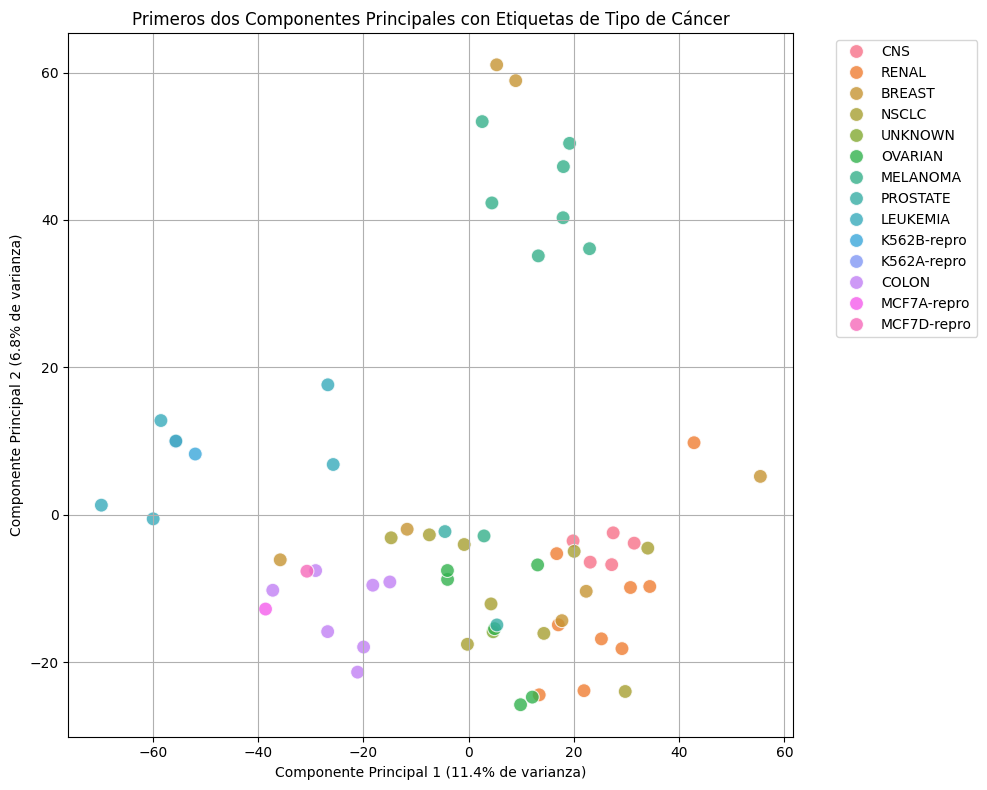

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Obtener los dos primeros componentes principales
pc1 = X_pca[:, 0]
pc2 = X_pca[:, 1]

# Crear un DataFrame para facilitar la graficación con seaborn
pca_df = pd.DataFrame({'PC1': pc1, 'PC2': pc2, 'label': y.values.flatten()})

plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='label', data=pca_df, s=100, alpha=0.8)
plt.title('Primeros dos Componentes Principales con Etiquetas de Tipo de Cáncer')
plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.1f}% de varianza)')
plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.1f}% de varianza)')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### **6.4. Reflexión sobre la Cantidad de Clústeres: K-Means vs. Agrupamiento Jerárquico**

En la sección de K-Means, se planteó la pregunta de si se seleccionó el número correcto de clústeres. Es importante recordar que en **K-Means**, la elección de $K$ es un paso crítico y a menudo subjetivo, apoyado por métodos como el del codo o el coeficiente de la silueta. Para el análisis anterior, sugerimos $K=3$ o $K=4$ basándonos en el método del codo, pero finalmente utilizamos $K=5$ para mantener la consistencia con ciertas visualizaciones, reconociendo la complejidad de un agrupamiento perfecto con etiquetas biológicas tan heterogéneas.

Sin embargo, la belleza del **Agrupamiento Jerárquico** radica precisamente en que **no requiere la especificación previa del número de clústeres ($K$)**. En su lugar, este algoritmo construye una jerarquía completa de agrupamientos, que se visualiza mediante un **dendrograma**. A partir del dendrograma, podemos decidir *a posteriori* cuántos clústeres cortar, observando las distancias entre las uniones de los grupos. Esto nos da una flexibilidad mucho mayor para explorar diferentes niveles de granularidad en la estructura de los datos, lo que es especialmente útil en contextos donde el número de grupos naturales no es conocido de antemano o puede variar según el nivel de detalle que se desee.

### **6.5. Agrupamiento Jerárquico: Creación del Dendrograma**

Ahora aplicaremos el algoritmo de agrupamiento jerárquico utilizando la librería `scipy`. Usaremos el método de enlace `'complete'` y la métrica de disimilitud `'euclidean'` sobre los datos PCA seleccionados. Finalmente, visualizaremos la jerarquía resultante mediante un dendrograma monocromático, lo que nos permitirá identificar visualmente las agrupaciones formadas.

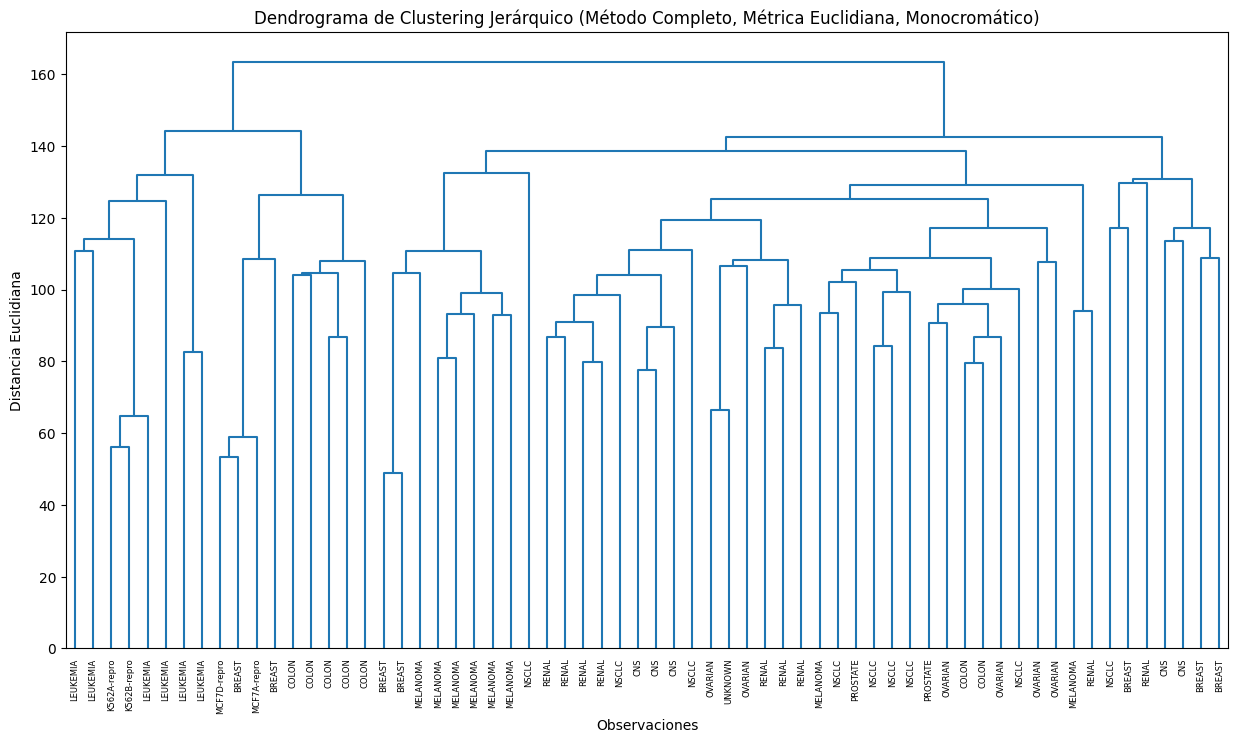

In [66]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Realizar el clustering jerárquico
# 'complete' es el método de enlace
# 'euclidean' es la métrica de distancia
linked_data = linkage(X_scaled, method='complete', metric='euclidean')

# Visualizar el dendrograma
plt.figure(figsize=(15, 8))
dendrogram(linked_data,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True,
           labels=y.values.flatten(),
           color_threshold=0) # Añadir color_threshold=0 para que sea monocromático
plt.title('Dendrograma de Clustering Jerárquico (Método Completo, Métrica Euclidiana, Monocromático)')
plt.xlabel('Observaciones')
plt.ylabel('Distancia Euclidiana')
plt.show()

#### **Interpretación del Dendrograma**

Un **dendrograma** es una representación gráfica en forma de árbol que muestra la jerarquía de agrupamientos generados por el Agrupamiento Jerárquico. Su interpretación es fundamental para entender las relaciones de similitud entre las observaciones:

*   **Cada hoja** (extremo inferior del árbol) representa una observación individual de nuestro conjunto de datos (en este caso, una línea celular del NCI60).
*   **Conforme subimos por el árbol**, las hojas se unen para formar ramas. Estas uniones indican que las observaciones o grupos de observaciones son similares entre sí.
*   **Observaciones que son similares entre sí** se agruparán en ramas cercanas y a niveles bajos del dendrograma.
*   **Entre más abajo es la unión** (más cerca del eje X), más similares son las observaciones o grupos de observaciones que se están uniendo. Esto significa que tienen una distancia de disimilitud menor.
*   **El eje Y** representa la **disimilitud** (o distancia) entre los clusters en el momento de su unión. Un corte horizontal a una cierta altura en el eje Y nos permite definir el número de clústeres. Las ramas que queden por debajo de ese corte formarán parte del mismo clúster.

En resumen, el dendrograma nos permite visualizar cómo las líneas celulares se agrupan progresivamente, desde unidades individuales hasta un gran grupo que contiene todas las observaciones, y nos ayuda a identificar los clústeres 'naturales' en diferentes niveles de granularidad.

### **6.6. Dendrogramas Policomáticos para Diferentes Cantidades de Clusters**

Ahora, vamos a generar dendrogramas policromáticos para visualizar la formación de 2, 3 y 4 clusters. Para lograr esto, calcularemos un `color_threshold` específico para cada caso. Este umbral indicará la altura en el dendrograma donde se realiza el 'corte' para obtener el número deseado de clusters, coloreando las ramas por debajo de este umbral de manera diferente.

Utilizaremos la función `fcluster` para determinar el umbral de altura que resulta en el número exacto de clusters que queremos visualizar. Esto nos permite ver claramente las agrupaciones a diferentes granularidades.

#### **6.6.1. Dendograma - 2 Clústeres**

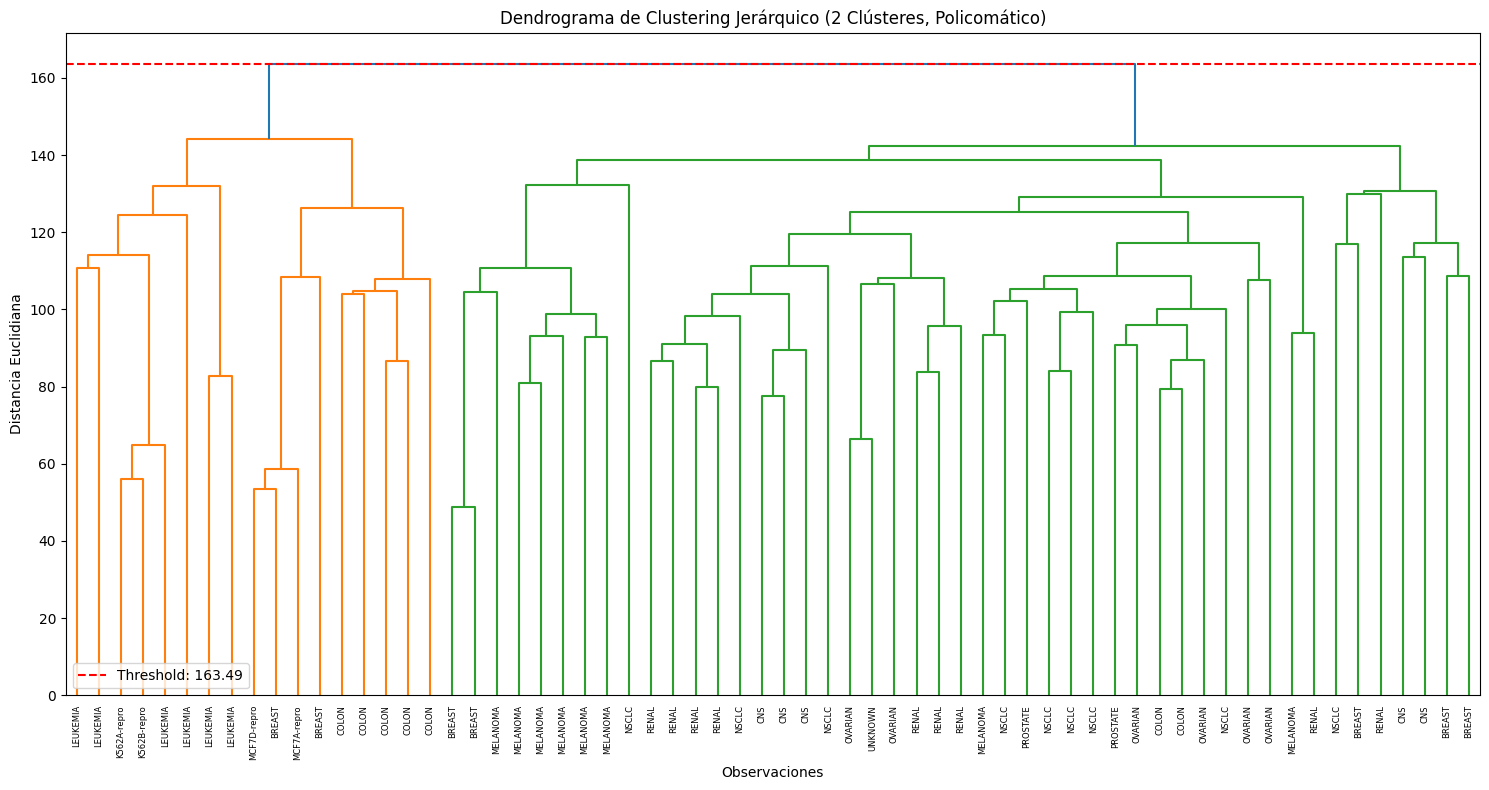

In [72]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Dendrograma para 2 Clústeres

num_samples = len(y)

# Calculamos el umbral para 2 clústeres
num_target_clusters = 2
threshold_2_scalar = linked_data[num_samples - num_target_clusters, 2]

plt.figure(figsize=(15, 8))
dendrogram(linked_data,
           labels=y.values.flatten(),
           leaf_rotation=90,
           distance_sort='descending',
           show_leaf_counts=True,
           color_threshold=threshold_2_scalar)
plt.axhline(y=threshold_2_scalar, color='r', linestyle='--', label=f'Threshold: {threshold_2_scalar:.2f}')
plt.title("Dendrograma de Clustering Jerárquico (2 Clústeres, Policomático)")
plt.xlabel('Observaciones')
plt.ylabel('Distancia Euclidiana')
plt.legend()
plt.tight_layout()
plt.show()

#### **6.6.2. Dendograma - 3 Clústeres**

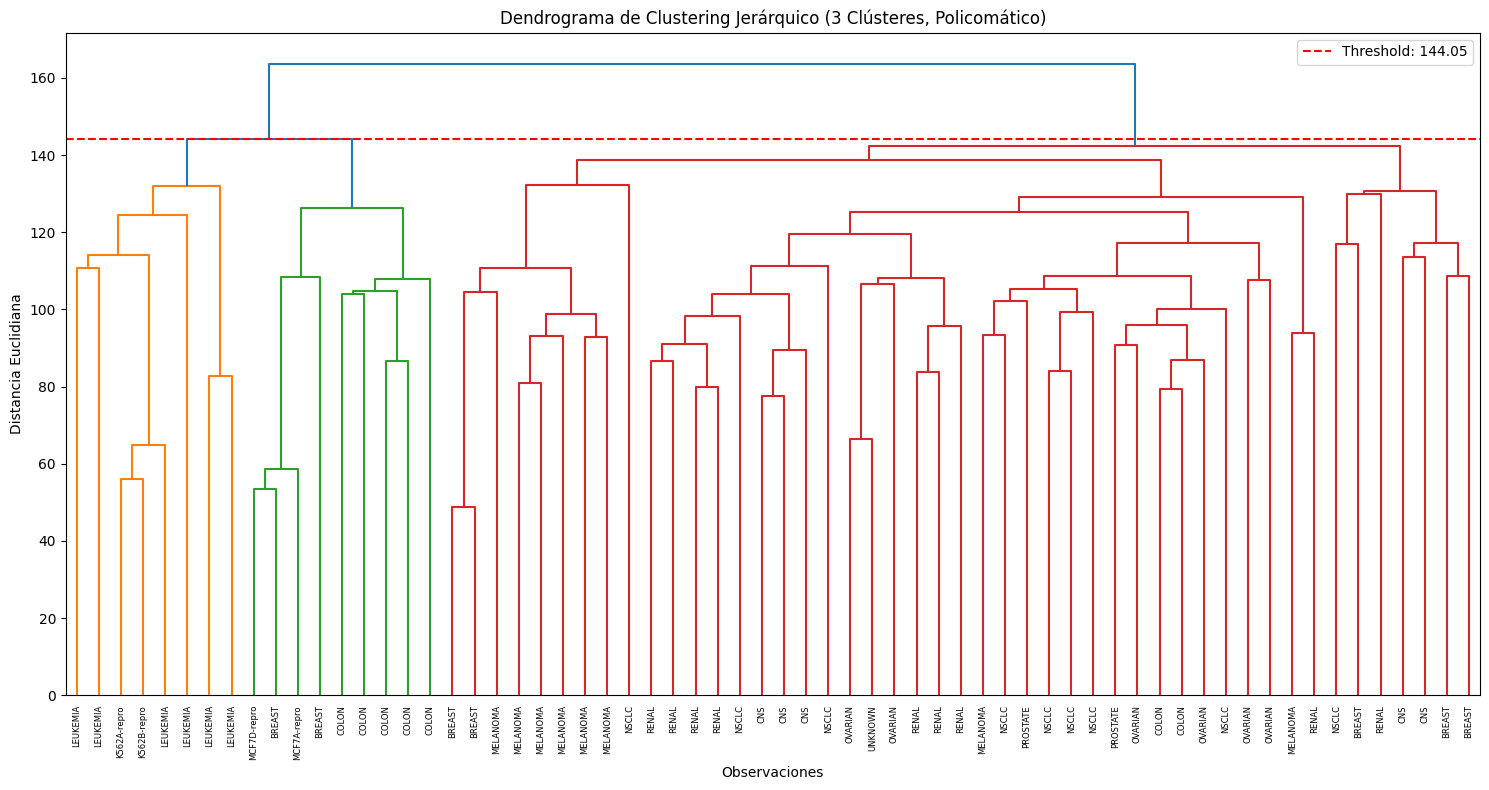

In [73]:
# Dendrograma para 3 Clústeres

num_samples = len(y)

# Calculamos el umbral para 3 clústeres
num_target_clusters = 3
threshold_3_scalar = linked_data[num_samples - num_target_clusters, 2]

plt.figure(figsize=(15, 8))
dendrogram(linked_data,
           labels=y.values.flatten(),
           leaf_rotation=90,
           distance_sort='descending',
           show_leaf_counts=True,
           color_threshold=threshold_3_scalar)
plt.axhline(y=threshold_3_scalar, color='r', linestyle='--', label=f'Threshold: {threshold_3_scalar:.2f}')
plt.title("Dendrograma de Clustering Jerárquico (3 Clústeres, Policomático)")
plt.xlabel('Observaciones')
plt.ylabel('Distancia Euclidiana')
plt.legend()
plt.tight_layout()
plt.show()

#### **6.6.3. Dendograma - 4 Clústeres**

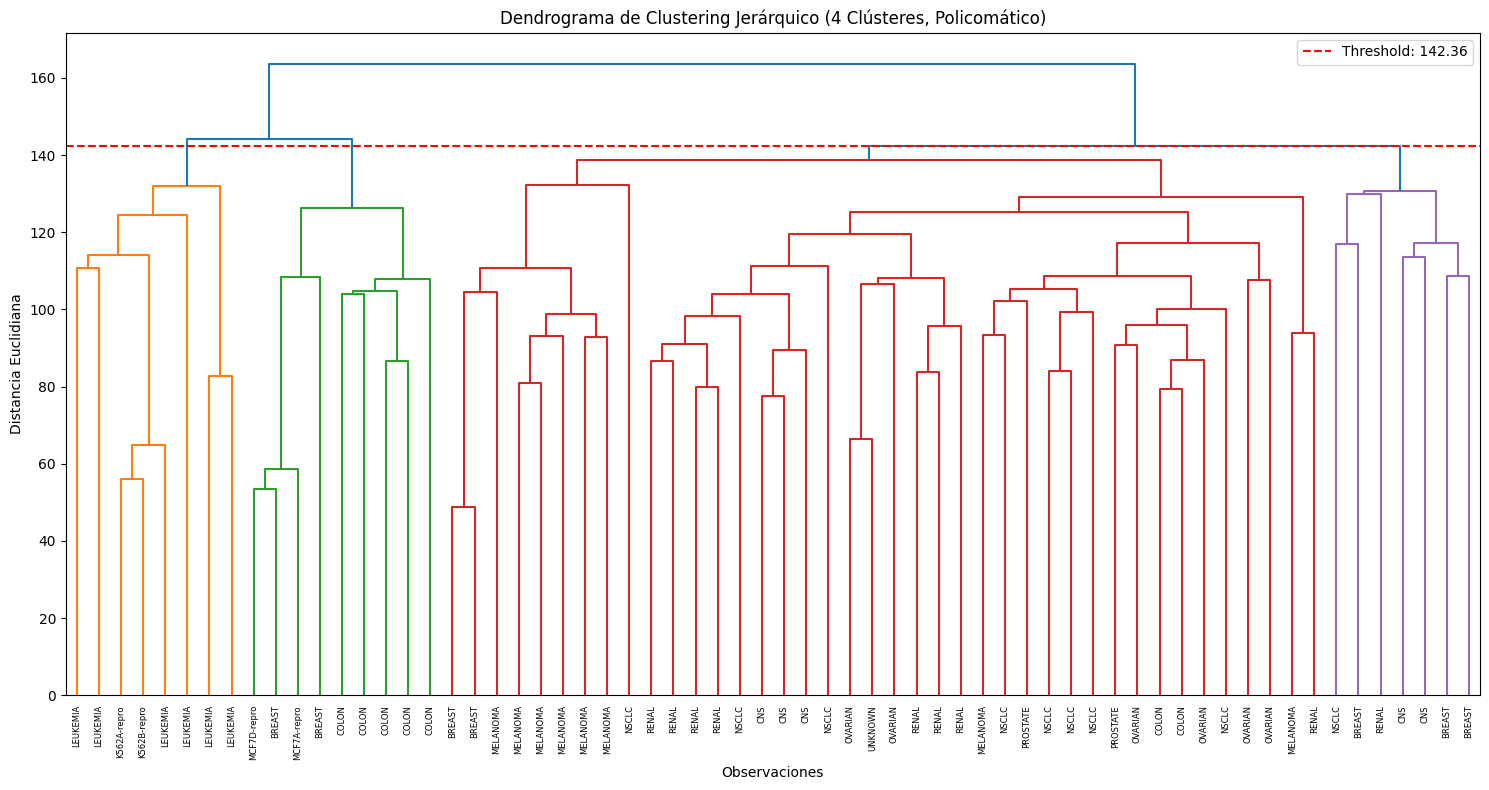

In [74]:
# Dendrograma para 4 Clústeres

num_samples = len(y)

# Calculamos el umbral para 4 clústeres
num_target_clusters = 4
threshold_4_scalar = linked_data[num_samples - num_target_clusters, 2]

plt.figure(figsize=(15, 8))
dendrogram(linked_data,
           labels=y.values.flatten(),
           leaf_rotation=90,
           distance_sort='descending',
           show_leaf_counts=True,
           color_threshold=threshold_4_scalar)
plt.axhline(y=threshold_4_scalar, color='r', linestyle='--', label=f'Threshold: {threshold_4_scalar:.2f}')
plt.title("Dendrograma de Clustering Jerárquico (4 Clústeres, Policomático)")
plt.xlabel('Observaciones')
plt.ylabel('Distancia Euclidiana')
plt.legend()
plt.tight_layout()
plt.show()

### **6.7 Agrupamiento Jerárquico con Métrica de Correlación**

Ahora, exploraremos el agrupamiento jerárquico utilizando una métrica de disimilitud diferente: la **correlación**. Mientras que la distancia euclidiana se enfoca en la magnitud y el volumen de las diferencias entre observaciones, la correlación se centra en las **tendencias o perfiles de comportamiento** de los genes. Esto es particularmente útil en el análisis de expresión génica, donde el patrón de co-expresión puede ser más informativo que las diferencias absolutas de expresión.

Utilizaremos el método de enlace `'complete'` y la métrica `'correlation'` sobre los datos `X_scaled` (datos originales estandarizados), para luego visualizar el dendrograma resultante de forma monocromática y compararlo con el obtenido previamente con la distancia euclidiana.

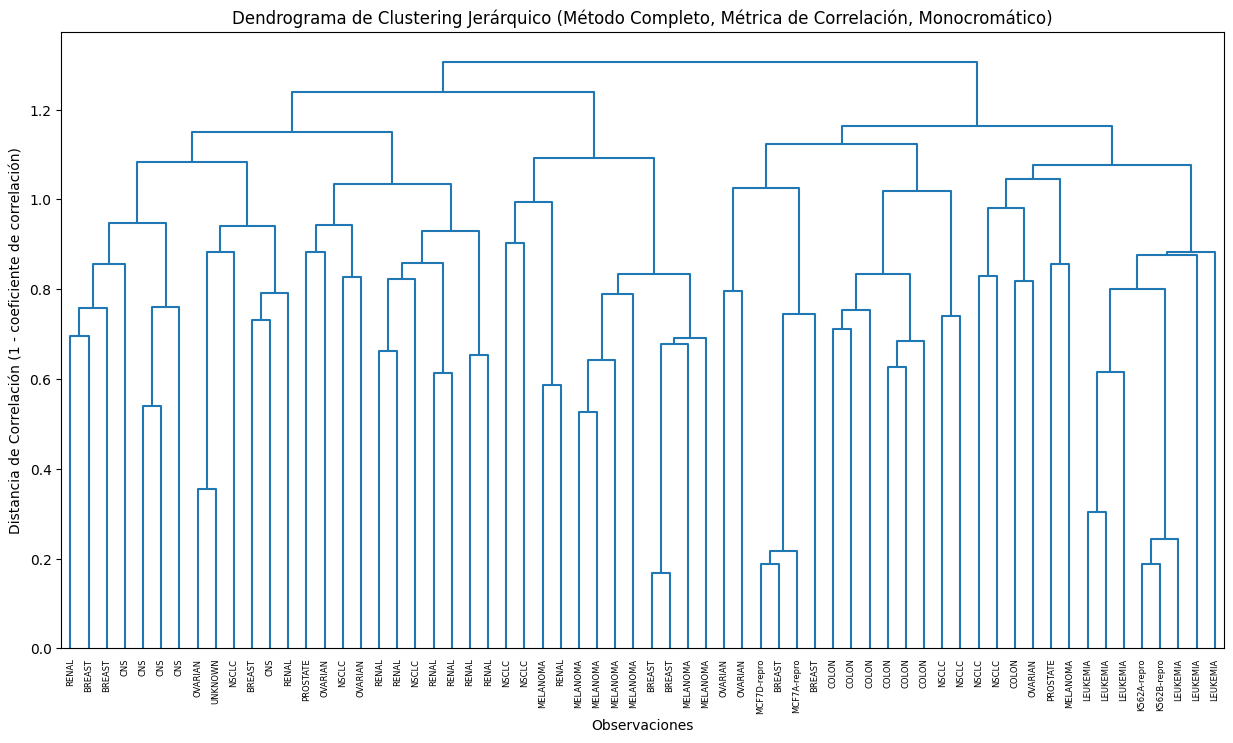

In [75]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Realizar el clustering jerárquico con métrica de correlación
# 'complete' es el método de enlace
# 'correlation' es la métrica de disimilitud
linked_correlation_data = linkage(X_scaled, method='complete', metric='correlation')

# Visualizar el dendrograma monocromático
plt.figure(figsize=(15, 8))
dendrogram(linked_correlation_data,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True,
           labels=y.values.flatten(),
           color_threshold=0) # Para un dendrograma monocromático
plt.title('Dendrograma de Clustering Jerárquico (Método Completo, Métrica de Correlación, Monocromático)')
plt.xlabel('Observaciones')
plt.ylabel('Distancia de Correlación (1 - coeficiente de correlación)')
plt.show()

#### **6.7.1. Comparación entre Dendrogramas: Distancia Euclidiana vs. Correlación**

Al comparar el dendrograma generado con la **métrica de correlación** con el anterior (métrica euclidiana), podemos observar diferencias significativas en la estructura de los clústeres:



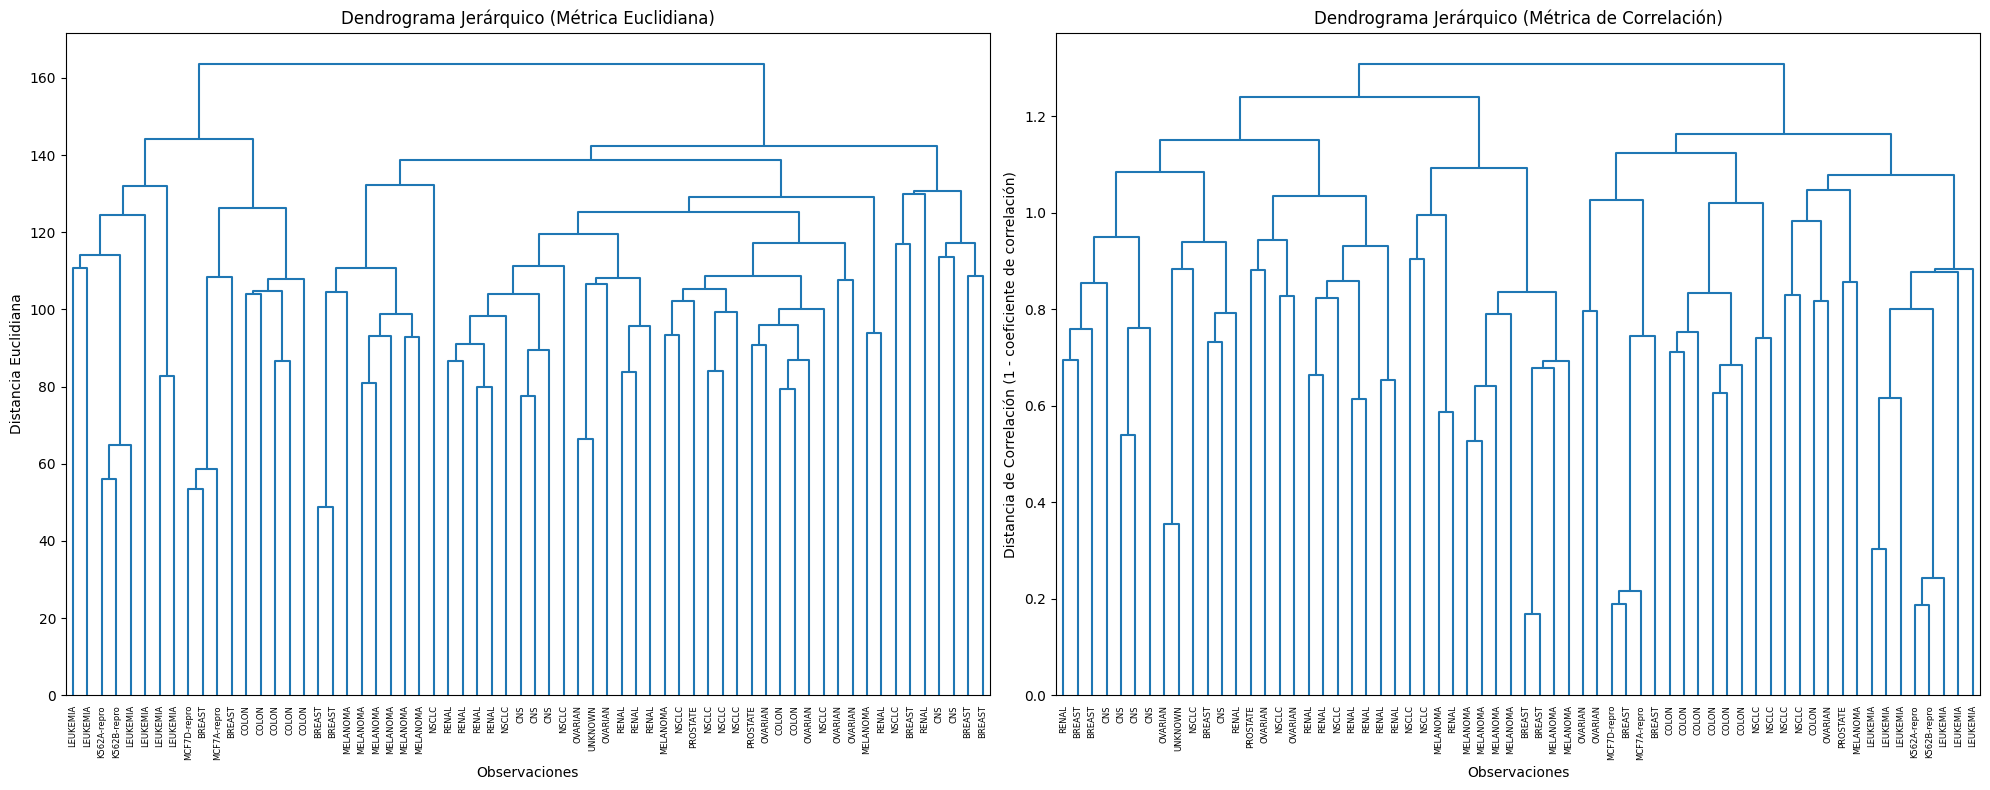

In [77]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 8))

# Dendrograma con Métrica Euclidiana
plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
dendrogram(linked_data,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True,
           labels=y.values.flatten(),
           color_threshold=0) # Monocromático
plt.title('Dendrograma Jerárquico (Métrica Euclidiana)')
plt.xlabel('Observaciones')
plt.ylabel('Distancia Euclidiana')

# Dendrograma con Métrica de Correlación
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
dendrogram(linked_correlation_data,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True,
           labels=y.values.flatten(),
           color_threshold=0) # Monocromático
plt.title('Dendrograma Jerárquico (Métrica de Correlación)')
plt.xlabel('Observaciones')
plt.ylabel('Distancia de Correlación (1 - coeficiente de correlación)')

plt.tight_layout()
plt.show()

*   **Enfoque de la Métrica:**
    *   **Euclidiana:** Agrupa observaciones que son **cercanas en el espacio euclidiano**, es decir, que tienen valores de expresión génica similares en magnitud. Las ramas se unen a una altura que indica la distancia absoluta entre los puntos.
    *   **Correlación:** Agrupa observaciones que tienen **patrones de expresión génica similares**, independientemente de la magnitud absoluta. Es decir, si dos líneas celulares muestran que sus genes suben y bajan juntos (o de forma inversa), serán agrupadas, incluso si los niveles de expresión absolutos son diferentes. La altura de unión representa 1 menos el coeficiente de correlación (una mayor altura indica menor correlación).

*   **Impacto en la Formación de Clústeres:** La elección de la métrica influye directamente en qué observaciones se consideran "similares" y, por lo tanto, en la formación de los clústeres. Es probable que el dendrograma basado en correlación revele agrupaciones que reflejan la co-regulación génica o subtipos biológicos con perfiles de expresión coherentes, mientras que el euclidiano podría agrupar por niveles generales de expresión.

*   **Interpretación:** Para el análisis de expresión génica, la métrica de correlación a menudo proporciona una visión biológicamente más relevante de las relaciones entre las líneas celulares, ya que se centra en cómo varían los genes conjuntamente, lo cual es fundamental para entender vías biológicas y subtipos de enfermedades.

### **6.8. Método de Enlace 'Average' (Enlace Promedio)**

El método de enlace 'Average' (o enlace promedio) es una de las estrategias utilizadas en el agrupamiento jerárquico para calcular la disimilitud entre dos clústeres. A diferencia del enlace 'Complete' (que considera la distancia máxima entre los puntos de dos clústeres), el método 'Average' calcula la distancia promedio entre **todos los pares de observaciones** que pertenecen a los dos clústeres.

Esta aproximación tiende a producir clústeres con tamaños más uniformes y es menos sensible a los valores atípicos, ya que promedia las distancias en lugar de depender de un único par de puntos (como en el 'complete' o 'single' linkage). Es una opción robusta que busca un equilibrio en la forma de los clústeres.

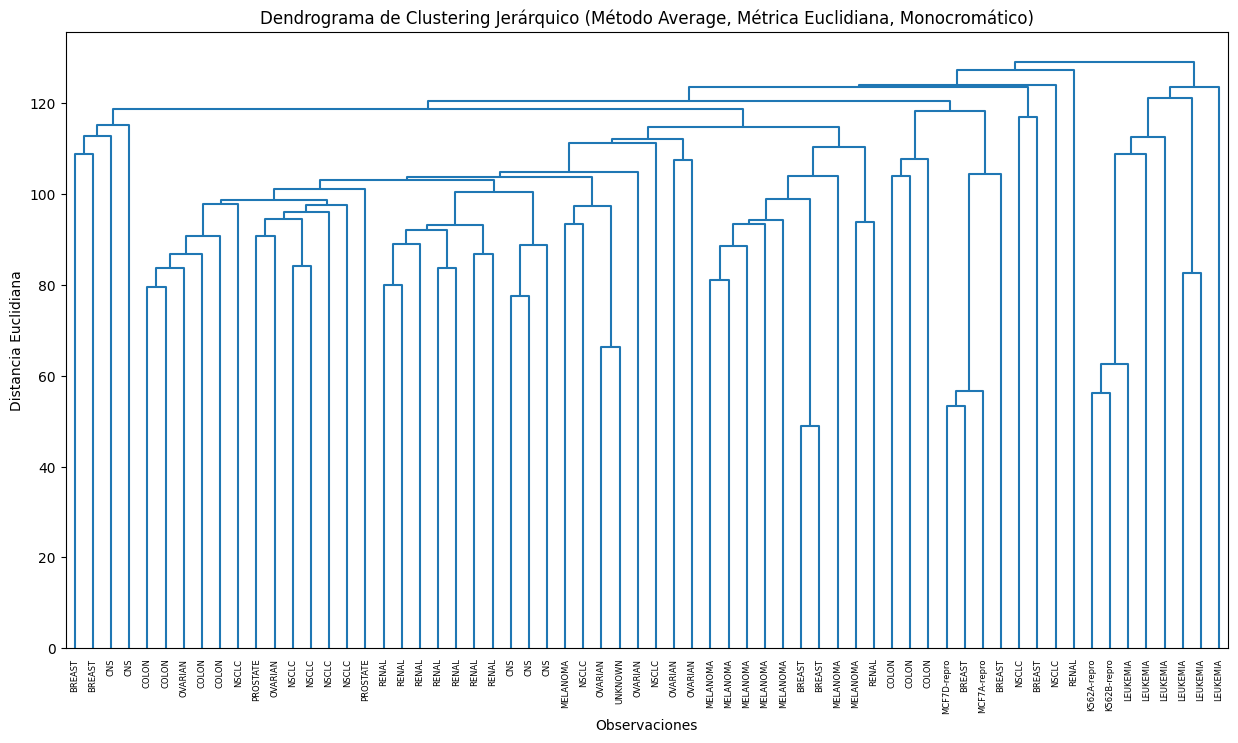

In [78]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Realizar el clustering jerárquico con métrica euclidiana y método 'average'
linked_average_euclidean_data = linkage(X_scaled, method='average', metric='euclidean')

# Visualizar el dendrograma monocromático
plt.figure(figsize=(15, 8))
dendrogram(linked_average_euclidean_data,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True,
           labels=y.values.flatten(),
           color_threshold=0) # Para un dendrograma monocromático
plt.title('Dendrograma de Clustering Jerárquico (Método Average, Métrica Euclidiana, Monocromático)')
plt.xlabel('Observaciones')
plt.ylabel('Distancia Euclidiana')
plt.show()

### **6.8.1. Comparación de Dendrogramas: Métrica y Método de Enlace**

Ahora tenemos tres dendrogramas principales para comparar, cada uno utilizando diferentes configuraciones de métrica de disimilitud y/o método de enlace:

1.  **Método `Complete`, Métrica `Euclidean`**: Tiende a producir clústeres más compactos y es sensible a los valores atípicos, ya que busca maximizar la distancia entre los miembros más lejanos de los clústeres.
2.  **Método `Complete`, Métrica `Correlation`**: Agrupa observaciones con patrones de expresión génica similares, independientemente de la magnitud. Esto es a menudo más relevante biológicamente para datos de expresión génica, ya que se enfoca en la co-regulación.
3.  **Método `Average`, Métrica `Euclidean`**: Calcula la distancia promedio entre todas las observaciones en dos clústeres para decidir su unión. Es menos sensible a los valores atípicos que el método 'complete' y tiende a producir clústeres con tamaños más uniformes.

Visualicemos los tres dendrogramas monocromáticos juntos para una mejor comparación.

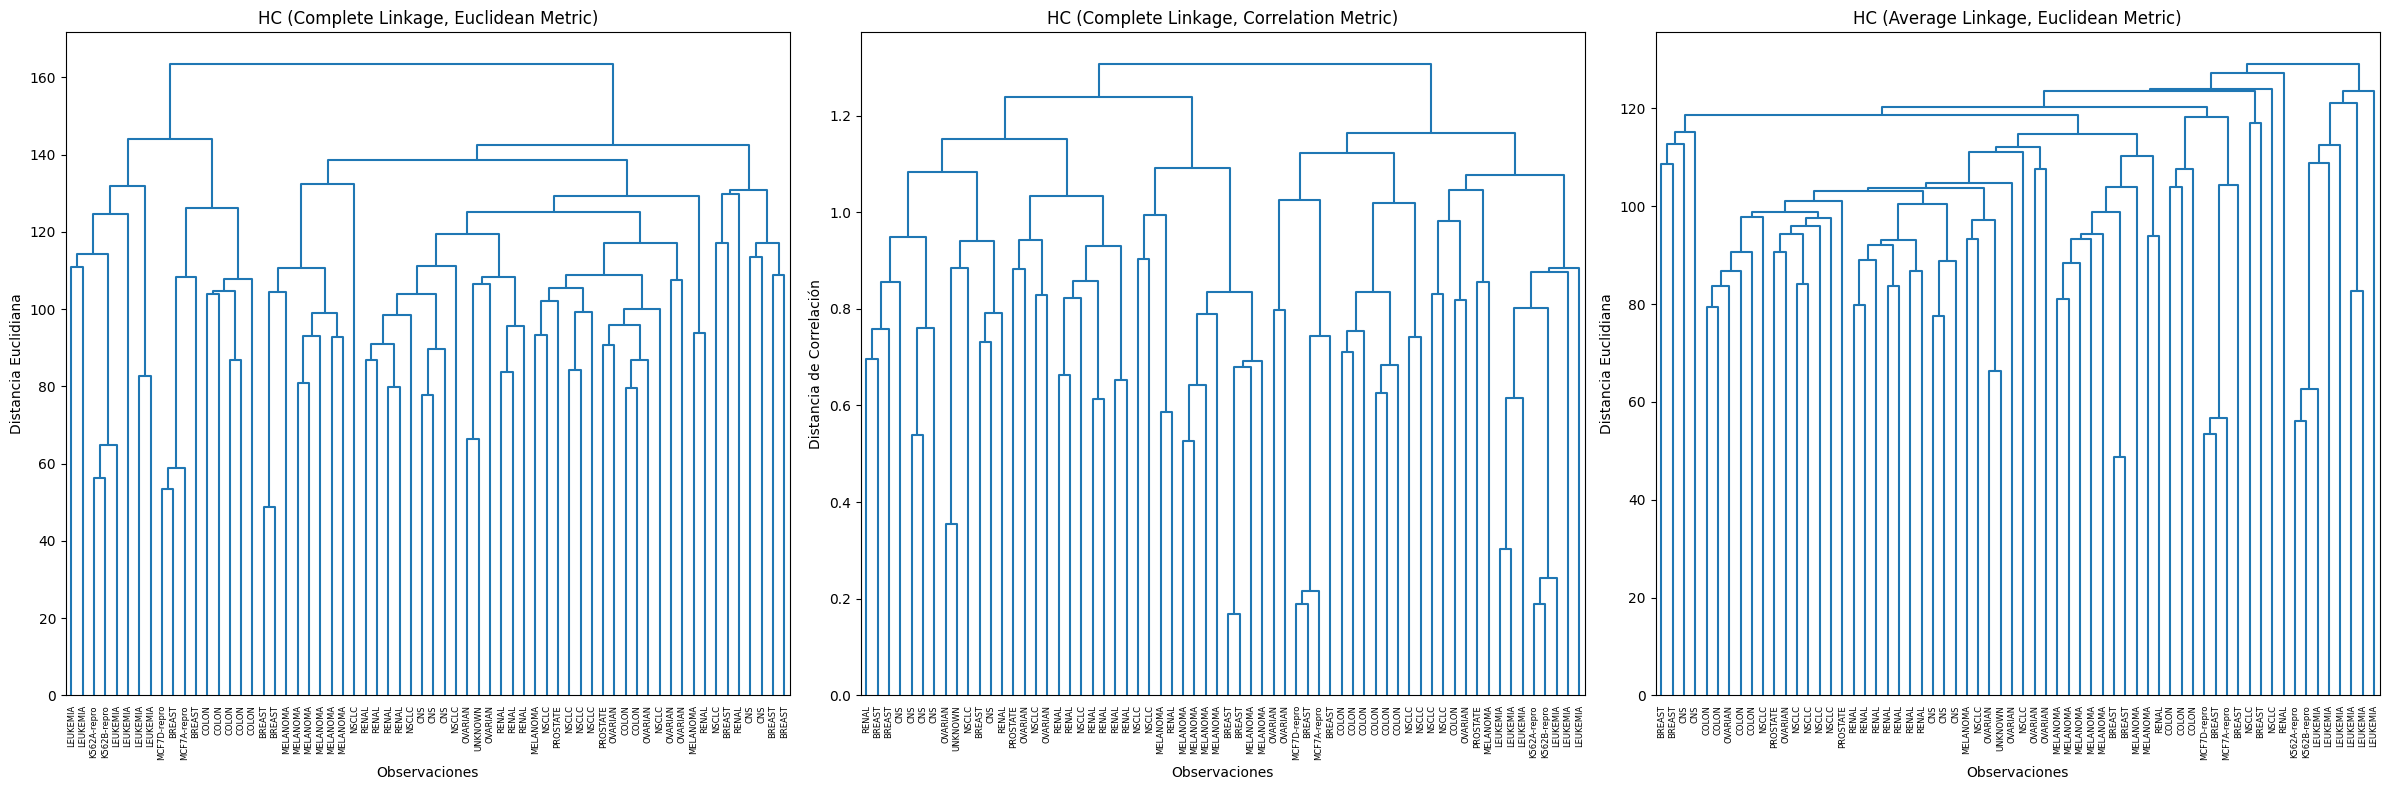

In [79]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

plt.figure(figsize=(24, 8))

# Dendrograma 1: Método Complete, Métrica Euclidiana
plt.subplot(1, 3, 1) # 1 fila, 3 columnas, primer gráfico
dendrogram(linked_data,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True,
           labels=y.values.flatten(),
           color_threshold=0) # Monocromático
plt.title('HC (Complete Linkage, Euclidean Metric)')
plt.xlabel('Observaciones')
plt.ylabel('Distancia Euclidiana')

# Dendrograma 2: Método Complete, Métrica de Correlación
plt.subplot(1, 3, 2) # 1 fila, 3 columnas, segundo gráfico
dendrogram(linked_correlation_data,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True,
           labels=y.values.flatten(),
           color_threshold=0) # Monocromático
plt.title('HC (Complete Linkage, Correlation Metric)')
plt.xlabel('Observaciones')
plt.ylabel('Distancia de Correlación')

# Dendrograma 3: Método Average, Métrica Euclidiana
plt.subplot(1, 3, 3) # 1 fila, 3 columnas, tercer gráfico
dendrogram(linked_average_euclidean_data,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True,
           labels=y.values.flatten(),
           color_threshold=0) # Monocromático
plt.title('HC (Average Linkage, Euclidean Metric)')
plt.xlabel('Observaciones')
plt.ylabel('Distancia Euclidiana')

plt.tight_layout()
plt.show()

### **6.9. Resumen Comparativo de los Métodos de Agrupamiento Jerárquico**

Al comparar los tres dendrogramas, observamos cómo la elección de la métrica de disimilitud y el método de enlace impactan en la formación de clústeres:

*   **HC (Complete Linkage, Euclidean Metric)**:
    *   **Énfasis:** Agrupa puntos que son cercanos en magnitud. Tiende a formar clústeres compactos y de forma esférica, buscando mantener la distancia máxima entre clústeres unidos.
    *   **Uso:** Adecuado cuando las diferencias absolutas de las características son lo más importante y se desean clústeres bien separados.

*   **HC (Complete Linkage, Correlation Metric)**:
    *   **Énfasis:** Agrupa puntos que tienen patrones de comportamiento similares, independientemente de sus valores absolutos. Para datos de expresión génica, esto es crucial para identificar co-regulación.
    *   **Uso:** Ideal en bioinformática o análisis de series temporales, donde la forma o tendencia del perfil es más relevante que la magnitud, como en el caso de los patrones de expresión génica.

*   **HC (Average Linkage, Euclidean Metric)**:
    *   **Énfasis:** Agrupa clústeres basándose en la distancia promedio de todos sus miembros. Busca un equilibrio en el tamaño y la forma de los clústeres.
    *   **Uso:** Es una opción robusta y menos sensible a valores atípicos que el 'Complete Linkage', produciendo clústeres más uniformes en general.

### **6.10. Casos de Uso Reais para Cada Método de Agrupamiento Jerárquico**

La elección del método de enlace y la métrica de disimilitud en el Agrupamiento Jerárquico no es arbitraria; depende del tipo de datos, el dominio del problema y lo que se busca entender de las relaciones entre las observaciones. Aquí se describen casos de uso reales para las combinaciones analizadas, con un enfoque en diferentes áreas:

#### **1. HC (Complete Linkage, Euclidean Metric)**

*   **Énfasis:** Agrupa puntos que son cercanos en magnitud absoluta, formando clústeres compactos.
*   **Caso de Uso Real (Área: Manufactura/Control de Calidad):**
    *   **Detección de Lotes Defectuosos:** Agrupar lotes de productos fabricados basándose en múltiples mediciones físicas (ej. dimensiones, peso, pureza). Este método sería ideal para identificar lotes que son muy consistentes y uniformes en sus especificaciones absolutas, distinguiéndolos de lotes que presentan valores absolutos significativamente diferentes, lo que podría indicar defectos de producción.

#### **2. HC (Complete Linkage, Correlation Metric)**

*   **Énfasis:** Agrupa observaciones que tienen patrones o tendencias de comportamiento similares, independientemente de sus valores absolutos.
*   **Caso de Uso Real (Área: Bioinformática/Genómica):**
    *   **Identificación de Subtipos de Enfermedades:** En el análisis de expresión génica (como el dataset NCI60), agrupar muestras de pacientes basándose en la correlación de sus perfiles de expresión de miles de genes. Esto ayuda a identificar subtipos de enfermedades con respuestas biológicas similares, incluso si los niveles absolutos de expresión de los genes varían entre pacientes, ya que el enfoque está en cómo los genes 'suben' y 'bajan' juntos.

#### **3. HC (Average Linkage, Euclidean Metric)**

*   **Énfasis:** Calcula la distancia promedio entre todos los pares de observaciones en dos clústeres para decidir la unión. Tiende a formar clústeres con tamaños más uniformes y es menos sensible a los valores atípicos.
*   **Caso de Uso Real (Área: Marketing/Segmentación de Clientes):**
    *   **Segmentación de Clientes por Comportamiento de Compra:** Agrupar clientes de una tienda basándose en su gasto promedio en diferentes categorías de productos (ej. electrónica, ropa, alimentos). El enlace promedio ayudaría a formar grupos de clientes que, en promedio, tienen patrones de gasto equilibrados en estas categorías, creando segmentos más robustos para campañas de marketing personalizadas, sin que un gasto extremadamente alto en una sola categoría domine el agrupamiento.

## **7. Conclusión Final: Desvelando Patrones con K-Means y Agrupamiento Jerárquico**

A lo largo de este tutorial, hemos explorado en profundidad dos de las técnicas fundamentales del aprendizaje no supervisado: **K-Means Clustering** y **Agrupamiento Jerárquico**. Ambas metodologías son herramientas poderosas para desvelar estructuras y patrones ocultos en conjuntos de datos complejos, como el de expresión génica NCI60, sin la necesidad de etiquetas preexistentes.

### **La Sinergia del Preprocesamiento: El Rol Crucial del PCA**

Un hallazgo central ha sido la indispensable necesidad del **Análisis de Componentes Principales (PCA)**. Al transformar datos de alta dimensionalidad (como los miles de genes del NCI60) a un espacio de menor dimensión, PCA no solo reduce el ruido y la complejidad computacional, sino que también facilita la visualización y mejora significativamente la capacidad de los algoritmos de clustering para identificar agrupaciones significativas. La elección de la cantidad óptima de componentes principales es un equilibrio entre retener información esencial y simplificar la estructura de los datos.

### **K-Means: Eficiencia y Agrupaciones Definidas**

**K-Means** se ha presentado como un método eficiente y directo, ideal cuando el número de clústeres ($K$) es conocido o puede estimarse razonablemente. Su naturaleza iterativa, basada en la asignación de puntos a centroides y la actualización de estos, tiende a formar clústeres esféricos y compactos. Hemos visto cómo su desempeño se beneficia enormemente del preprocesamiento con PCA, aunque su sensibilidad a la inicialización y la necesidad de definir $K$ de antemano son consideraciones importantes. Su utilidad brilla en escenarios donde la velocidad y la identificación de grupos con características de magnitud similar son prioritarias.

### **Agrupamiento Jerárquico: Flexibilidad y Visión Multi-Escala**

El **Agrupamiento Jerárquico** ofrece una perspectiva más flexible al construir una jerarquía completa de clústeres, visualizada a través del **dendrograma**. Esta representación en forma de árbol permite explorar las relaciones de similitud entre las observaciones a diferentes niveles de granularidad, sin la necesidad de especificar $K$ de antemano. La elección del **método de enlace** (como 'Complete' o 'Average') y la **métrica de disimilitud** (como 'Euclidean' o 'Correlation') son decisiones críticas que dictan cómo se define la 'similitud' entre grupos y, por ende, la estructura de los clústeres resultantes. Esta adaptabilidad lo hace invaluable en campos como la bioinformática, donde patrones de co-regulación génica pueden ser más relevantes que las diferencias absolutas de expresión.

### **La Importancia de la Elección y la Interpretación**

Ambas técnicas, K-Means y Agrupamiento Jerárquico, son herramientas poderosas, pero su aplicación exitosa no es universal. La elección del algoritmo, el preprocesamiento de los datos, y la configuración de parámetros como $K$, el método de enlace o la métrica de disimilitud, deben estar guiadas por el dominio del problema y los objetivos específicos del análisis. La clave reside en una **interpretación crítica y contextualizada** de los resultados, que va más allá de las métricas estadísticas para buscar una significancia práctica y biológica.

### **Aplicaciones en el Mundo Real**

Los algoritmos de clustering no son solo conceptos académicos; son herramientas esenciales en diversas industrias:

*   **Salud y Bioinformática**: Identificación de subtipos de enfermedades basados en perfiles genéticos (como en el NCI60), agrupación de pacientes para tratamientos personalizados.
*   **Marketing y Ventas**: Segmentación de clientes basada en comportamientos de compra o demografía para campañas dirigidas.
*   **Finanzas**: Detección de fraudes mediante la identificación de patrones de transacciones anómalas.
*   **Manufactura y Control de Calidad**: Agrupación de productos para identificar defectos o variaciones en la producción.
*   **Redes Sociales**: Detección de comunidades o grupos de interés entre usuarios.

En conclusión, el mastering de estas técnicas, combinado con una comprensión profunda de los datos y los objetivos del negocio, capacita a los analistas de datos para extraer conocimiento valioso, impulsar la innovación y tomar decisiones informadas en un mundo cada vez más impulsado por los datos.